# TADF — Framework Evolution: the Decision Artifact from v1 to v2.2

**Scope of this notebook.** The Phase 2a notebook (`results_analysis.ipynb`, Sections 4–5) derived **TADF v1** from the final grid and froze it there; the Phase 2b notebook (`results_analysis_phase2b.ipynb`, Sections 5–7) evolved it to **v1.1** and **v1.2** and consolidated the framework into a two-artifact structure. Per the versioning decision of IT-062, neither notebook is edited retroactively — the design trajectory stays inspectable (Hevner et al. 2004, G6; Gregor & Hevner 2013). This notebook is the third element of that discipline: it **documents the trajectory across versions in one place** and then takes the next design steps: **TADF v1.3**, after an external expert review **TADF v1.4**, the three-layer consolidation **TADF v1.5**, the structural correction **TADF v2.0**, the checked two-table restructuring **TADF v2.1**, and the scoring finalization **TADF v2.2** (scoring rulebook, T-criterion admission rule, removal of the band-equal runtime-structure criterion, and the newly *measured* extraction criterion after the pre-registered IT-069 sweep):

- **Framework 1 — the TADF Reference Architecture** (knowledge domains, six dimensions, capability check, outcome diamond; Phase 2b notebook, Section 6) — **unchanged** through v2.1; in **v2.2** re-formalized as the **Conceptual Architecture Decision Model for Subtask Routing in Agentic Systems** (Section 5.11), whose four decision steps mirror the Decision Sheet's blocks one-to-one.
- **Framework 2 — the decision layer** that the architect actually uses to make the routing decision (in v1.2: the TADF-Core five-question card plus the 7-category reference table) — **re-formalized as the TADF Decision Sheet**: a screening stage (yes/no questions that fix the architecture when they fire) followed by a weighted preference-scoring stage (architect-entered weights against evidence-anchored paradigm scores), with per-question evidence provenance and a mechanical verification. v1.4 adds, from the review: the explicit subtask scope (the sheet routes *isolated LLM subtasks*, hybrid architectures emerge from the pipeline), Stage 0 (LLM necessity & atomicity), the corrected control-flow criterion in Q2, build rules B1/B2, and mandatory-minimum flags in the scoring stage — every element tagged **measured** or **derived** against the frozen evidence.

**Data discipline.** No raw results are re-analyzed here. Every number cited below is taken from the frozen evidence bases of the two analysis notebooks (final grid, Phase 2b family grids; temperature 0, seed 42; single-run readings bounded by the 10.2% temperature-0 flip rate — pattern claims only).

| Version | Evidence state | Artifact form | Where it lives | Status |
|---|---|---|---|---|
| **v1** | Phase 2a final grid (A–H, 3 tiers) | Gate cascade + 3 complementary views (hierarchy, swimlane, 7-category table with amber placeholders) | `results_analysis.ipynb` §4–5 | frozen (IT-062) |
| **v2 candidate** | Phase 2a | Strict hierarchical tree (one dimension per level) | `results_analysis.ipynb` §4.1 | **refuted** by family X (IT-059) |
| **v1.1** | + families P, X, L, M | Updated decision table (rows 1.2, 2.3, 3.1, 3.3, 3.4 resolved) | `results_analysis_phase2b.ipynb` §5 | superseded |
| **v1.2** | + family S | Table update (row 2.1 split) + two-artifact consolidation (Reference Architecture · TADF-Core) | `results_analysis_phase2b.ipynb` §5–7 | current evidence state |
| **v1.3** | same evidence as v1.2 | Framework 2 as the two-stage **TADF Decision Sheet** (hard-break screening + weighted preference scoring), verified for completeness and v1.2 equivalence | this notebook, §5 + §6 changelog (form preserved in repo history) | superseded by v1.4 |
| **v1.4** | same evidence + external expert review (2026-07-30) | Decision Sheet with subtask scope, Stage 0, control-flow Q2, build rules, mandatory minima; every element tagged measured/derived; verified with controlled divergence | this notebook, §5.2 + §6 changelog | superseded by v1.5 |
| **v1.5** | same content as v1.4 | **Three-layer structure**: Core Decision Sheet · design knowledge · evidence base; verified as pure re-representation | this notebook, §6 changelog | superseded by v2.0 |
| **v2.0** | same evidence; v1.2 better-choice semantics restored | Mandatory-constrained fit matrix; M-invariance, neutral equivalence, intended divergence | this notebook, §6 changelog | superseded by v2.1 |
| **v2.1** | same evidence; author's two-table proposal, adoption-checked | Stage 1 gates (Q1–Q5) + Stage 2 weighted paradigm fit (T-criteria fixed weight 3, P1–P6 with 0–3 or M); three corrections from re-running every measured case | this notebook, §6 changelog | superseded by v2.2 |
| **v2.2** | + IT-069 B1 map-form sweep (pre-registered) | **Scoring finalization**: explicit scoring rulebook (banding, admission, P-derivations); band-equal runtime-structure criterion removed (kept as build form W2); extraction criterion **measured** (W2/A3 per the pre-registered decision rule); full 30-group corpus backtest; **Framework 1 re-formalized** as the Conceptual Architecture Decision Model (§5.11) | **this notebook**, Section 5 | **current — frozen** for the evaluation phase (IT-071) |

Author: Steffen Niesmann · TADF research repository · 2026-07-30

## Requirements

The notebook needs `matplotlib` only (figures are drawn, not loaded). All tables are generated from in-notebook rule data — there is no dependency on `data/results/`.

In [1]:
%pip install -q matplotlib

Note: you may need to restart the kernel to use updated packages.


*What the next cell does:* imports, the house palette shared with the two analysis notebooks (workflow blue, agent purple, state-machine teal, decompose amber), and a small HTML display helper.

In [2]:
import itertools
from IPython.display import HTML, display
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

plt.rcParams.update({'axes.grid': True, 'grid.alpha': 0.3, 'axes.axisbelow': True})

# House palette (identical to results_analysis.ipynb / results_analysis_phase2b.ipynb)
C_WF = '#5b8db8'   # LLM workflow
C_AG = '#9b7fbf'   # agent loop
C_SM = '#5aa08a'   # state-machine workflow (family S)
C_DC = '#c9a25e'   # decompose
C_GATE = '#f4f4f4'
C_NEUTRAL = '#eef1f3'

def show_html(s):
    display(HTML(s))

print('Setup complete.')

Setup complete.


## 1. The design trajectory at a glance

*What the next cell does:* draws the version timeline — each framework version anchored to the iteration-log entries (IT‑###) that produced it, with the refuted v2 hierarchy as a terminated branch. Solid boxes are released versions; the dashed box is the refuted candidate; the amber box is the new step taken in this notebook.

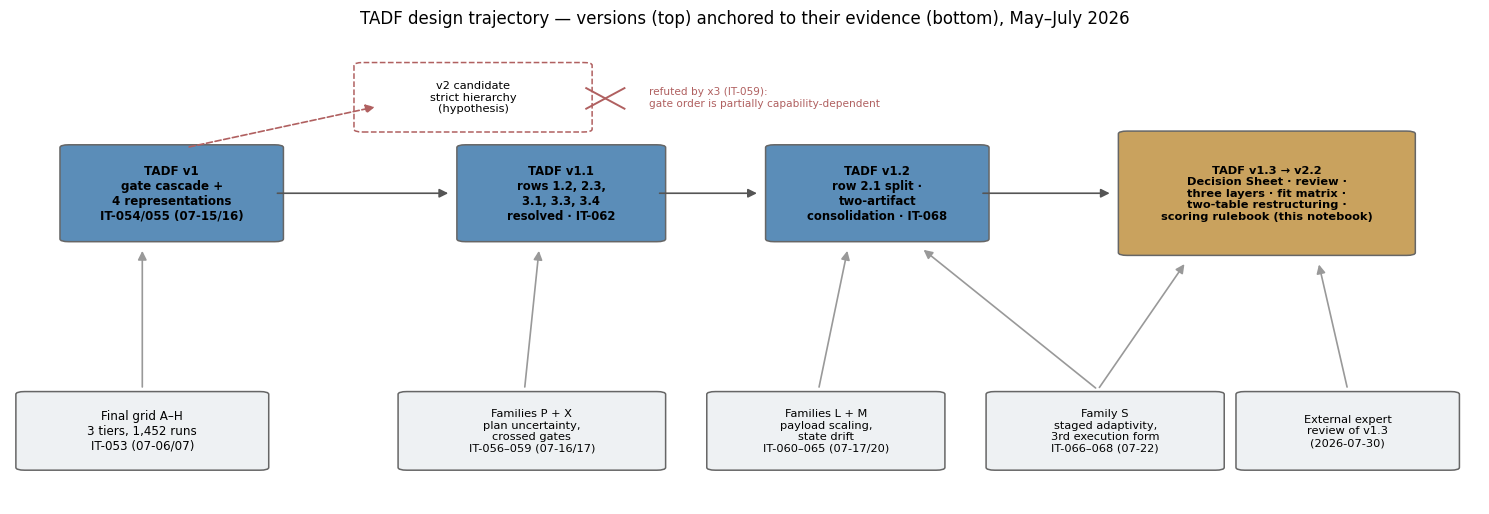

In [3]:
f, ax = plt.subplots(figsize=(15, 5.2))
ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis('off'); ax.grid(False)

def box(x, y, w, h, text, fc, ec='#666666', ls='solid', fontsize=8.6, weight='normal'):
    p = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.6', fc=fc, ec=ec, ls=ls, lw=1.1)
    ax.add_patch(p)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=fontsize, weight=weight)

def arrow(x1, y1, x2, y2, ls='solid', color='#555555'):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='-|>',
                                 mutation_scale=13, color=color, ls=ls, lw=1.2))

# evidence lane (bottom)
box( 1, 8, 16, 16, 'Final grid A–H\n3 tiers, 1,452 runs\nIT-053 (07-06/07)', C_NEUTRAL)
box(27, 8, 17, 16, 'Families P + X\nplan uncertainty,\ncrossed gates\nIT-056–059 (07-16/17)', C_NEUTRAL, fontsize=8.2)
box(48, 8, 15, 16, 'Families L + M\npayload scaling,\nstate drift\nIT-060–065 (07-17/20)', C_NEUTRAL, fontsize=8.2)
box(67, 8, 15, 16, 'Family S\nstaged adaptivity,\n3rd execution form\nIT-066–068 (07-22)', C_NEUTRAL, fontsize=8.2)

# version lane (top)
box( 4, 58, 14, 20, 'TADF v1\ngate cascade +\n4 representations\nIT-054/055 (07-15/16)', C_WF, weight='bold')
box(24, 82, 15, 14, 'v2 candidate\nstrict hierarchy\n(hypothesis)', 'white', ec='#b06060', ls='dashed', fontsize=8.2)
box(31, 58, 13, 20, 'TADF v1.1\nrows 1.2, 2.3,\n3.1, 3.3, 3.4\nresolved · IT-062', C_WF, weight='bold', fontsize=8.4)
box(52, 58, 14, 20, 'TADF v1.2\nrow 2.1 split ·\ntwo-artifact\nconsolidation · IT-068', C_WF, weight='bold', fontsize=8.4)
box(76, 55, 19, 26, 'TADF v1.3 → v2.2\nDecision Sheet · review ·\nthree layers · fit matrix ·\ntwo-table restructuring ·\nscoring rulebook (this notebook)', C_DC, weight='bold', fontsize=8.2)
box(84, 8, 14, 16, 'External expert\nreview of v1.3\n(2026-07-30)', C_NEUTRAL, fontsize=8.2)
arrow(91, 25, 89, 53, color='#999999')

arrow(18, 68, 30, 68)
arrow(44, 68, 51, 68)
arrow(66, 68, 75, 68)
arrow(12, 78, 25, 87, ls='dashed', color='#b06060')
ax.text(43.5, 89.0, 'refuted by x3 (IT-059):\ngate order is partially capability-dependent', fontsize=7.6,
        ha='left', va='center', color='#b06060')
ax.plot([39.2, 41.8], [86.5, 91.0], color='#b06060', lw=1.4)
ax.plot([39.2, 41.8], [91.0, 86.5], color='#b06060', lw=1.4)

# evidence -> version feeds
arrow( 9, 25,  9, 56, color='#999999')
arrow(35, 25, 36, 56, color='#999999')
arrow(55, 25, 57, 56, color='#999999')
arrow(74, 25, 62, 56, color='#999999')
arrow(74, 25, 80, 53, color='#999999')

f.suptitle('TADF design trajectory — versions (top) anchored to their evidence (bottom), May–July 2026', fontsize=12)
plt.tight_layout()
plt.show()

### Findings — how to read the trajectory

Three properties of this trajectory carry over into everything below. First, **every version increment is an evidence event, not an editorial one**: v1 exists because the final grid was interpreted (IT‑054), v1.1 because four deep-dive families resolved the amber rows (IT‑057/059/061/065), v1.2 because family S measured the compiled-branching boundary instead of arguing it (IT‑068). Second, **refutation is a first-class result**: the v2 hierarchy candidate was built to be falsifiable, and family X's discriminating cell x3 falsified it — gate order is partially capability-dependent, so the cascade (a priority list, not a strict tree) remains the citable form. Third, **representation and content are versioned separately**: v1.3 below changes the *form* of the decision layer (Framework 2) while leaving its *content* — the v1.2 evidence state — untouched, and Section 5.7 verifies that claim mechanically.

## 2. TADF v1 — the Phase 2a state (frozen)

TADF v1 turned the final grid (8 archetypes × 2 paradigms × 3 model tiers, 1,452 runs) into the routing artifact. Its core is the **gate cascade**, walked top-to-bottom per task node, first leaf wins; gate order encodes evidence strength (structural > rule-based > search > enumeration). *Decompose* is a first-class third outcome, and a Stage‑3 capability check applies to every leaf.

| Gate | Question (short form) | Outcome on fire | Key evidence (final grid) |
|---|---|---|---|
| **S0** | Too loaded for one execution? (≥6 simultaneous constraints · 3+ cross-system fields in one answer · per-item pre-resolution) | **DECOMPOSE** | H-high 1/25 W vs 0/25 A · B-high 8/25 vs 10/25 · f-med-5 0/5 both |
| **G1** | Does the plan depend on what execution reveals? | **AGENT** | F runtime-feedback: W 0/15 vs A 13/15, tier-invariant; even one read-conditional branch breaks it (f-med-2: 1/5 vs 5/5) |
| **G2** | Can the decision logic be written down as stable, fetchable rules? | **WORKFLOW + rule engine** | D: 75/75 at 903±4 tokens vs 60/75 at ~5.6k; 12 of 15 agent errors permissive — the dangerous direction |
| **G3** | Must the search build on its own intermediate answers? | **AGENT** (exception: simple lookup at low error consequence → workflow, IT‑012) | A-high: W 56% vs A 92%; gap narrows with capability, never flips |
| **G4** | Does every item in a bulk action need different arguments? | **AGENT** | f-med-3 (9 heterogeneous): 2/5 vs 5/5 · f-med-4 (16 identical): 5/5 both — variety, not volume |
| **default** | — | **WORKFLOW + deterministic middle layer** | agent's 2.6–3.5× token premium bought no additional success where no gate fired (D, H); C at ceiling — either paradigm |

v1 shipped in **four representations with a declared division of purpose** (IT‑055): the **cascade** (§4) as the architect's walkthrough and citable form, the **hierarchical tree** (§4.1) as the labelled v2 *hypothesis*, the **swimlane process view** (§4.2) as the top-level evaluation flow, and the **decision table** (§4.3) as the master artifact — 7 categories, 20 questions, colour-coded (red = hard break, normal = better choice, **amber = placeholder to be calibrated in Phase 2b**).

**What v1 explicitly left open (the amber cells):** payload/context sizing thresholds (row 1.2), state drift mid-run (row 2.3), unknown call count (row 3.3), unknown tool/step (row 3.4), the v1-cascade-vs-v2-hierarchy representation question (agenda item 9), and all quantitative gate thresholds (single-cell calibration, flagged for Phase 3 practitioner validation). These ambers are exactly what Phase 2b was designed to close — the four families P (plan uncertainty), X (crossed gates), L (payload scaling), M (moving target) were selected as the build decision at the end of the Phase 2a notebook.

## 3. TADF v1.1 — after families P, X, L, M

The four deep-dive families resolved the amber rows. Changelog v1 → v1.1 (full derivations in `results_analysis_phase2b.ipynb`, Sections 1–4):

| Row | v1 state | Phase 2b evidence | v1.1 state |
|---|---|---|---|
| 1.2 payload | amber placeholders `[c₁] [b₁] [a₁] [a₂]` | Family L: success invariant up to ≈19k (W) / ≈41k (A) input tokens; volume is a **cost lever, not a correctness gate**; no success cliff observed | calibrated as a recommendation; later **reclassified from routing to build** (context sizing, row 7.2) — no threshold fabricated |
| 2.3 state drift | amber, under test | Family M: **observable** drift m1 W 0/25 vs A 25/25 (tier-invariant, cleanest separation of Phase 2b); **silent** drift m2 0/25 both — 20.6k agent tokens buy nothing | observable drift → **AGENT, hard break** (G1 mechanism extended to environment dynamics); silent drift **excluded from routing** — a paradigm-independent build mandate (atomic writes, freshness re-checks) |
| 3.1 heterogeneity | hard break on heterogeneous enumeration | x3: bounded rule-generated variety W 1/10 nano · 4/10 mini · **5/5 reference** (≈3× cheaper than agent) | refined: hard break applies to **unbounded per-item** variety only; bounded rule-generated variety is **capability-conditional** (Stage 3) |
| 3.3 call count unknown | amber, under test | P-a (count derivable from a read): 25/25 both, W 0.36× tokens · P-b (count depends on runtime outcomes): W **0/25 structural zero** vs A 15/25 | **split**: data-bounded count → workflow (better choice) · outcome-dependent count → **AGENT, hard break** |
| 3.4 source unknown | amber, under test | P-c (fact lives in exactly one of mailbox/calendar/CRM): A 24/25 vs W 12/25; capability narrows, never closes | → **AGENT, hard break** |
| representation | v2 hierarchy = hypothesis | x1 (D4×D1): W 0/25 at every tier — **G1 ⊐ G2 order confirmed** · x3: D3 ⊐ D4 holds only below the reference tier | **cascade confirmed as the citable form; static hierarchy refuted** — gate order is partially capability-dependent |
| build notes | teasers only | L mail anomaly (quoted-query fidelity bug); both paradigms mis-quote, only the agent *observes* the empty result | new build notes: emptiness check + bounded re-plan · placeholder guard · parallel dispatch (≥~40 actions) · atomic/idempotent tools · race-safe simulations |

Two method rules also date from this stage: *both-paradigm zeros trigger a gold review* (P‑d gold bug found and fixed), and *simulation fidelity is part of the artifact* (the L mail anomaly was a tool bug, not a paradigm result — diagnosed, fixed, re-swept).

## 4. TADF v1.2 — family S, the third execution form, and the two-framework consolidation

**The question S answered.** The structural zeros behind rows 2.1/3.3b (x1 0/25, P‑b 0/25) were zeros *of the canonical two-stage form*. A workflow with **compiled conditional edges** — deterministic branch selection over enumerated tool outcomes, every LLM call at plan time — is still a workflow by the Section 2.2 definition and might recover them. That was the strongest open objection to gate 2.1, so it was measured instead of argued (IT‑066): the **state-machine workflow (SM)**, a third execution form beside canonical workflow and agent.

**What S found** (125 runs + P‑c re-check, IT‑068):

- **s1** (rule-on-outcome, the former x1 zero): SM **19/25 pooled, 5/5 at the reference tier** at ~5.0k tokens vs the agent's ~14.4k (0.35×). The x1 zero was a *limit of the two-stage form, not of compiled control flow*.
- **s2** (repeat-until-refusal, the former P‑b zero): SM **14/25 pooled, 5/5 at reference** at ~5.2k vs ~19.1k (0.27×). An outcome-dependent *count* is SM-compatible when the stop condition is deterministically checkable on a structured response.
- **s3** (runtime results must flow into generated report *content*): canonical W 2/25, SM 4/25, **agent 13/25** (4/5 at reference). The control instance s3‑4 (no refusal → content plan-time derivable) passes in all three forms at reference — isolating the mechanism: **path selection is compilable, content synthesis is not.**
- **P‑c re-check** at reference: combined 5/10 (W) vs 9/10 (A) — the row 3.4 hard break stands; the small-n caveat is closed.

**Changelog v1.1 → v1.2:** row 2.1 **splits** — *(a)* build-time-enumerable structured outcomes + deterministic branch tests + bounded depth → **compiled conditional workflow (state machine) from the reference tier** (capability-conditional below; Stage 3 carries the condition); *(b)* runtime-dependent **content**, non-enumerable outcomes, or unbounded depth → **AGENT, hard break confirmed**. TADF-Core Q1 gains the sub-question *"…and can every branch input be enumerated at build time from structured tool responses?"*; the workflow build checklist gains item 10 (the state-machine option). Scope kept honest: the S evidence covers enumerable outcome spaces of *one* transactional tool with structured responses; free-text outcome interpretation and novel outcome categories remain agent territory.

### The consolidation: two frameworks, three layers

Phase 2b's Section 6 consolidated TADF into the structure this notebook builds on:

| | Artifact | Content | Architect's use |
|---|---|---|---|
| **Framework 1** | **TADF Reference Architecture** | Four knowledge domains the architect assembles (**Task Context** per task · **Tool Landscape** and **System Architecture** per environment · **Deployment Context** per deployment) feeding six dimensions — three *gates* (Task Boundary, Runtime Dependence, Plan Expressibility), three *rankings* (Error Exposure & Auditability, Efficiency, Evolvability) — with the cross-cutting **Capability Check** and the outcome diamond Workflow / Agent / Decompose | once per environment + once per task: gather the knowledge the decision consumes ("prevents checking without knowing") |
| **Framework 2** | **The decision layer** | in v1.2: the TADF-Core five-question card + the 7-category v1.2 reference table (red/normal/amber), with the build checklists attached at the outcome | per task: make the routing decision; consult the table for thresholds and evidence grades |

**Why v1.3.** Framework 2 in its v1.2 form is complete in *content* but hard to execute in *form*: a prose question card on top of a 20-question colour-coded checklist, in which hard breaks, recommendations, and preferences are interleaved and the architect has no computed result at the end. Since Framework 2 is exactly the part practitioners execute, v1.3 restructures it into the form practitioners know from vendor and tool selection: a **two-stage decision instrument** — non-compensatory knock-out questions first, compensatory weighted scoring second, with a computed paradigm fit score at the bottom. That is the single design move of v1.3 — Section 5.

## 5. TADF v1.3 → v2.2 — Framework 2 as the TADF Decision Sheet

Section 5 develops Framework 2 through six design steps: **v1.3** (two-stage instrument), **v1.4** (external-review iteration; response table in 5.2), **v1.5** (three layers), **v2.0** (mandatory-constrained fit matrix — "better choice" and "structurally required" separated), **v2.1** (two-table restructuring, adoption-checked with three corrections), and **v2.2** (this state): the **scoring finalization** after the B1 confirmation sweep (IT‑069) closed the last derived routing element.

**What v2.2 fixes.** The capability scores and the criteria set are now governed by an explicit **scoring rulebook** (5.3a) instead of case-by-case judgment. Its central instrument is the **T-admission rule**: *a task-fit criterion is scored only if the experiments show at least a one-band success differential between the paradigms on the same measurement basis.* Two consequences:

1. **The former runtime-structure criterion leaves the scoring.** On its cells, pooled on the same basis, the state-machine workflow scores 58/75 = 77% and the agent 64/75 = 85% — **both band 2, no band-step differential**; at the reference tier both are 5/5. Its real, measured advantages — 0.27–0.36× tokens, near-constant cost, compiled control, schema output — are exactly P1/P2/P4 content and are counted **once**, there (the double-counting the review had flagged). The structure keeps its place as **build knowledge**: when Q4 is answered "no" because every relevant result maps to a predefined transition, the workflow build form is the state machine (**W2**, design knowledge; capability check C1).
2. **The measured item-binding criterion enters** as **T2 — Multi-item extraction success** (Workflow 2 / Agent 3, both sides measured, IT‑069). The task-fit block is now *Rule success* (3/2) · *Multi-item extraction success* (2/3) · *Retrieval success* (3/1) — the category names say what they are: the three structures with **band-level structural success advantages** in the experiments. Everything else that differs between the paradigms is either a gate (structural zeros), a deployment quality (P-block), or build knowledge (forms, rules, checks).

Stage 1 (Q1–Q5) is carried over from v2.1 unchanged in substance. Scoring: $S_p=\sum_i a_i w_i c_{i,p}$, task-fit weights fixed at 3, deployment weights 0–3 or **M** (weight 3 and non-compensable, capability ≥ 2), tie → workflow.

### 5.1 Methodical foundations

- **Stage 1 is a non-compensatory screening** (elimination by aspects, Tversky 1972; conjunctive screening, Hwang & Yoon 1981), formally a single-hit decision table (CODASYL 1982; Vanthienen & Dries 1994) — over the unit of analysis (Q1–Q3) and the measured structural zeros (Q4–Q5).
- **Stage 2 is a mandatory-constrained additive multi-attribute model** (SAW: Fishburn 1967; Hwang & Yoon 1981; Keeney & Raiffa 1976; Nutzwertanalyse, Zangemeister 1970) with conjunctive constraints via the M weight value. **Preferential independence is enforced by the scoring rulebook** (5.3a): capability scores follow metric-specific band rules, task-fit criteria require a same-basis band differential for admission, and every measured effect is counted exactly once (Keeney & Raiffa 1976).
- **Three layers** (core sheet · design knowledge · evidence base) per DSR practice (Gregor & Hevner 2013); decision-table comprehension: Huysmans et al. 2011.

**References.** Beach, L. R. (1990). *Image Theory.* Wiley. · CODASYL (1982). *A Modern Appraisal of Decision Tables.* ACM. · Fishburn, P. C. (1967). *Operations Research* 15(3). · Gregor, S. & Hevner, A. R. (2013). *MIS Quarterly* 37(2), 337–355. · Huysmans, J. et al. (2011). *DSS* 51(1), 141–154. · Hwang, C.-L. & Yoon, K. (1981). *Multiple Attribute Decision Making.* Springer. · Keeney, R. L. & Raiffa, H. (1976). *Decisions with Multiple Objectives.* Wiley. · Payne, J. W. (1976). *OBHP* 16(2), 366–387. · Tversky, A. (1972). *Psychological Review* 79(4), 281–299. · Vanthienen, J. & Dries, E. (1994). *Int. J. on AI Tools* 3(2), 267–288. · Zangemeister, C. (1970). *Nutzwertanalyse in der Systemtechnik.* Wittemann.

### 5.2 Design iteration v1.3 → v1.4 — response to the external review (historical)

| # | Review point | Decision | Where it lives in v2.2 |
|---|---|---|---|
| 1 | Scope precondition + LLM-necessity/atomicity screening | Adopted | Q1/Q2 |
| 2 | Granularity as qualification, tested warning thresholds | Adopted | Q3 |
| 3 | Runtime criterion = control flow, not content | Adopted | Q4 + build rule B2 |
| 4 | Predictable states incl. per-state wording | Adopted | Q4 "no"-path → build form W2 + C1 (unscored since v2.2 by the admission rule) |
| 5 | Rules = extract-then-decide + completeness condition | Adopted | T1 / form W3 |
| 6 | Open-space vs known-store search | Adopted | Q5 vs T3 |
| 7 | Known per-item values ≠ agent | Adopted, then **measured** (IT‑069) | T2 (2/3) + B1 / form W4 |
| 8 | Weight 0 + mandatory minima | Adopted | Stage 2, M weight value |
| 9 | Capability scores = evidence-based defaults | Adopted | rulebook 5.3a + footnote |
| 10 | C6 repetition + idempotency | Adopted | C6 |

### 5.3 The sheet as data — single source of truth

*What the next cell does:* defines all layers as one data structure, including the **scoring rulebook** that every capability number is derived from.

In [4]:
# ---------------- Scoring rulebook (v2.2) — every number derives from a rule --
SCORING_RULEBOOK = [
    ("T capability bands",
     "Task-completion rate per paradigm, banded on the SAME pooled grid basis for both sides: "
     "≥90% → 3 · 50–89% → 2 · <50% (or completeness not deterministically verifiable) → 1. "
     "Band width exceeds the 10.2% temperature-0 flip noise; per-cell n = 5–25 makes finer "
     "grading unsupported."),
    ("T admission rule",
     "A task-fit criterion is SCORED only if the paradigms differ by at least one band on the "
     "same basis. Band-equal structures are not scored — they become build knowledge. Applied "
     "in v2.2: the former runtime-structure criterion (predefined states / checkable "
     "repeat-until / data-bounded iteration) is band-equal — state machine 58/75 = 77%, agent "
     "64/75 = 85%, both band 2 (reference tier: both 5/5) — and its measured advantages "
     "(0.27–0.36× tokens, near-constant cost, compiled control, schema output) are P1/P2/P4 "
     "content, counted once there. It remains as build form W2 (Q4 'no'-path note, check C1)."),
    ("P1 cost bands",
     "Token ratio to the cheaper paradigm per SOLVED task, computed over the region Stage 2 "
     "actually governs (no gate fired): ≤1.5× → 3 · ≤3× → 2 · >3× → 1. Workflow 1× → 3; agent "
     "median 3.6× (B 6.4 · D 7.7 · F 2.8 · H 2.1) → 1. Documented exceptions inside the "
     "region: C inverted (0.83× — chunk overhead) and E at parity (1.0×); agent cost also "
     "grows faster with payload (3–4× vs 2.3×, family L)."),
    ("P3 error-direction rule",
     "Share of errors in the dangerous direction: direction is a design choice (fail-closed "
     "engine; E strict bias 2:1 = safe direction) → 3 · uncontrolled and majority-dangerous "
     "(12/15 = 80% silent approvals) → 1."),
    ("P2/P4 construction rubric",
     "3 = guaranteed or mechanically checkable BY CONSTRUCTION · 2 = achievable by post-hoc "
     "validation or reconstruction · 1 = not controllable. Workflow: per-rule traces and "
     "schema output by construction → 3/3. Agent: transcripts reviewable but not per-rule "
     "attributable, output validatable post-hoc (needed dedicated robust extraction, IT-005) "
     "→ 2/2."),
    ("P5 scope + band",
     "Scoped to INPUT-SURFACE noise (messy input) and TCR-banded on the B robustness suite: "
     "agent 15/15 = 100% → 3, workflow 13/15 = 87% → 2. Counter-evidence cited by rule: under "
     "the D perturbations the workflow was the more robust side (18/18 vs 13/18) — the score "
     "does not generalize beyond input noise."),
    ("P6 status rule",
     "Not measured — derived from the row-6.1 migration path; no band possible; the only "
     "unmeasured Stage-2 score, validated in Phase 3 (amber)."),
]

# ---------------- Stage 1 — qualification & agent gates ------------------------
GATES = [
    dict(id="Q1", cat="LLM necessity", route="NO-LLM", status="derived",
         q="Can the required output be produced using only predefined deterministic logic?",
         spec="Answer yes if no semantic interpretation, context-dependent reasoning, or "
              "context-specific language generation is required — fixed business rules, "
              "database queries, schema transformations, arithmetic, fixed API orchestration, "
              "foreach over known values or already structured mappings. "
              "If yes: implement deterministically and stop.",
         ev="Derived from the §2.2 role confinement. The deterministic layer it routes to is "
            "the best-measured component of the evidence base: deterministic retrieval core "
            "15/15, rule engine 75/75, action executor flawless in every run — including all "
            "IT-069 runs, where every failure was an LLM binding step, never the foreach.",
         prov="§2.2 · IT-004/041/069"),
    dict(id="Q2", cat="Atomic responsibility", route="DECOMPOSE", status="measured",
         q="Does the subtask combine multiple executable and testable LLM responsibilities?",
         spec="Examples: researching and approving · extracting facts and applying rules · "
              "deciding and executing an irreversible action · executing actions and reporting "
              "their results. Atomicity refers to ONE coherent goal and success criterion, not "
              "to the number of LLM calls. If yes: decompose by responsibility and re-enter.",
         ev="Exactly these mixtures produced the zeros no paradigm buys back: a stop-dependent "
            "batch AND its run report in one execution — agent 13/25, both workflow forms "
            "≤4/25 (s3); after the split, each part has a measured or derived workflow form. "
            "Mixed-responsibility drafting (6+ rules at once): 4% vs 0%.",
         prov="s3, H-high · IT-066/068"),
    dict(id="Q3", cat="Granularity", route="DECOMPOSE", status="measured",
         q="Does the responsibility exceed the tested boundary of one reliable task execution?",
         spec="Tested warning conditions (not natural laws): six or more independent output "
              "requirements · semantic combination across three or more systems · a separate "
              "retrieval or reasoning process for each item. "
              "If yes: split along the limiting dimension and re-enter.",
         ev="Both paradigms fell to (near) zero at these thresholds: drafting under 6+ rules — "
            "4% vs 0%; one answer from three systems — 32% vs 40%; per-item lookups — 0 of 5 "
            "for both. Extra model budget did not help; split parts ran as workflows at about "
            "a third of the mixed task's agent cost.",
         prov="v1.2 row 1.1 · IT-054/059"),
    dict(id="Q4", cat="Adaptive control", route="AGENT", status="measured",
         q="Must the LLM select or create a next step that cannot be fully predefined?",
         spec="Answer yes if runtime observations require an OPEN choice of the next tool, "
              "action, intermediate step, or stopping point — including unexpected outcomes, "
              "outcome-dependent repetition whose stop condition CANNOT be checked "
              "deterministically, and observable state changes that require replanning. "
              "Answer no if predefined logic can map every relevant result to a defined "
              "transition — checkable repeat-until and data-bounded iteration included; in "
              "that case the workflow build form is the state machine (W2, design knowledge; "
              "check C1). Runtime-dependent data or output alone does not qualify (B2).",
         ev="The structural zeros of every pre-planned form: reacting to live data changes "
            "0/25 vs agent 25/25 at every model size (m1) — an instructed re-check mandate "
            "rescues only the agent (16/25 vs 0/25, m3); recovery from unexpected action "
            "outcomes 0/15 vs 13/15 (f-high); a single read-conditional branch broke the "
            "canonical form (1/5 vs 5/5, f-med-2). Enumerable branching is NOT gated: the "
            "state machine carries it (s1/s2 5/5 at reference vs canonical 0/25) — since "
            "v2.2 unscored build knowledge per the admission rule.",
         prov="rows 2.1/2.3 · IT-047/049/065/068"),
    dict(id="Q5", cat="Adaptive search", route="AGENT", status="measured",
         q="Does the subtask require adaptive search over an open or unknown search space?",
         spec="Answer yes if the next query or source depends on previous findings, the "
              "relevant source is unknown, or completeness cannot be verified "
              "deterministically in a semantically ambiguous search space AND a missed result "
              "would be costly. Answer no for known, enumerable sources with deterministic "
              "coverage checks (that is T3) and for cheap everyday lookups (workflow-equal "
              "and cheaper, IT-012).",
         ev="Open multi-step research: workflow 56% vs agent 92%; unknown source 5/10 vs 9/10 "
            "even at the strongest tier — the gap narrows, never flips, and the workflow's "
            "misses are silent.",
         prov="rows 2.2/3.4 · IT-012/033/042/057"),
]

# ---------------- Stage 2 — weighted paradigm fit (v2.2 task-fit block) --------
TFIT = [
    dict(id="T1", cat="Rule success", w=3, s_wf=3, s_ag=2, status="measured",
         q="Can the goal be reached by applying unambiguous written rules?",
         spec="Applies if the rules can be retrieved at runtime (policy store, thresholds, "
              "escalation matrix), the LLM only extracts the required case facts, and "
              "deterministic code applies the rules. Vague, conflicting, or discretionary "
              "rules do not qualify (consider human review).",
         ev="Band rule: workflow (form W3) 75/75 = 100% → 3; agent 60/75 = 80% → 2. The "
            "agent's error DIRECTION (12/15 silent approvals) is counted once, in P3. If the "
            "rules' input is a runtime outcome, Q4 governs (canonical form 0/25 there, x1).",
         prov="row 3.2 · IT-041/045/059"),
    dict(id="T2", cat="Extraction success", w=3, s_wf=2, s_ag=3, status="measured",
         q="Must different item-specific values be completely extracted from unstructured "
           "text and matched to the correct items?",
         spec="Applies when ONE natural-language input contains multiple item-value mappings "
              "that must be bound into separate actions (different owners, notes, fields, "
              "wording per item). Identical values across all items and already structured "
              "mappings do not qualify (Q1 territory). If each item first requires separate "
              "retrieval or open-ended judgment, Q3 or Q5 governs.",
         ev="Both sides measured (IT-069). Single combined plan object: 2/5. Per-item map "
            "calls (form W4): 2/3 = 67% → band 2 — binding was 9/9 wherever the inventory was "
            "right, but the one-shot inventory silently dropped 3 of 9 items in one run, and "
            "a pre-planned form cannot notice a missing item. Agent: 5/5 = 100% → band 3, at "
            "cost parity (~23k ≈ map form) — its loop tracks open items continuously. "
            "Mechanism: completeness over an unstructured enumeration (the transactional "
            "sibling of the multi-entity-search finding, IT-012).",
         prov="f-med-3/-4 · IT-015/069 · admitted in v2.2"),
    dict(id="T3", cat="Retrieval success", w=3, s_wf=3, s_ag=1, status="measured",
         q="Can the required information be retrieved from known and enumerable sources?",
         spec="Applies if all relevant sources are known and coverage can be checked through "
              "predefined querying, pagination, deduplication, and validation — including "
              "completeness-critical retrieval (criticality argues for stricter deterministic "
              "coverage, not for an agent).",
         ev="Band rule: workflow 15/15 = 100% → 3; agent 6/15 = 40% → 1 (lost itself in "
            "ad-hoc querying). The deterministic ETL core behind the workflow was separately "
            "validated 15/15.",
         prov="rows 2.2 (not-clause) · IT-004/033/043"),
]

PREFERENCES = [
    dict(id="P1", cat="Efficiency", crit="Efficiency & predictability",
         desc="Cost, latency, and budget predictability per solved task.",
         s_wf=3, s_ag=1,
         ev="Rulebook P1: agent median premium 3.6× per solved task over the governed region "
            "(B 6.4× · D 7.7× · F 2.8× · H 2.1×) → band 1; workflow near-constant cost "
            "(903±4 in the rule cells) → 3. Documented exceptions: C inverted (0.83×), E "
            "parity (1.0×); agent cost grows faster with payload (family L). Cost and "
            "latency are one criterion (identical pair, same mechanism). Bulk-output "
            "latency needs parallel dispatch (B5)."),
    dict(id="P2", cat="Governance", crit="Traceability & audit evidence",
         desc="Ability to reconstruct tool calls, retrieved evidence, state changes, and "
              "outputs after execution.",
         s_wf=3, s_ag=2,
         ev="Construction rubric: workflow traces are per-rule attributable by construction "
            "(3); agent transcripts and tool logs are reviewable but not per-rule "
            "attributable (2). The 11% judge-vs-deterministic-layer disagreement shows why "
            "traces must be mechanically checkable."),
    dict(id="P3", cat="Governance", crit="Safe failure direction",
         desc="Ability to constrain errors and uncertainty toward a predefined safe state "
              "(fail-closed behavior, human escalation).",
         s_wf=3, s_ag=1,
         ev="Error-direction rule: workflow direction is a design choice (fail-closed "
            "engine; E strict bias 2:1 = the safe direction, dual scoring per B10) → 3; "
            "agent errors were 80% silent approvals (12/15) → 1. Typical M flag in regulated "
            "deployments (excludes the agent)."),
    dict(id="P4", cat="Output control", crit="Output schema guarantee",
         desc="Is the output consumed by a system rather than a human? Weight high if it "
              "must conform to a fixed, machine-validated format (API payload, database "
              "record, ticket label, the typed input of the next node) where a malformed "
              "field breaks the downstream step; weight 0–1 if a human reads and can repair.",
         s_wf=3, s_ag=2,
         ev="Construction rubric: workflow emits schema-validated objects at every boundary "
            "by construction (3); agent output is free text requiring deterministic "
            "extraction and post-validation (2 — needed dedicated robust extraction, IT-005; "
            "batch classification was routed on exactly this guarantee at success parity, "
            "IT-019). Both forms crash structurally, differently, at the same low rate."),
    dict(id="P5", cat="Robustness", crit="Robustness to messy input",
         desc="Tolerance to noisy, informal, incomplete, or imperfectly structured input.",
         s_wf=2, s_ag=3,
         ev="Scoped to input-surface noise per the rulebook: B robustness suite — agent "
            "15/15 = 100% → 3, workflow 13/15 = 87% → 2. Counter-evidence cited by rule: "
            "under the D perturbations the workflow was the more robust side (18/18 vs "
            "13/18); input normalization helps both paradigms more than switching."),
    dict(id="P6", cat="Evolvability", crit="Flexibility under change",
         desc="Ability to accommodate changing task definitions or input distributions "
              "without substantial redesign.",
         s_wf=1, s_ag=3,
         ev="NOT measured — the only derived Stage-2 score (rulebook P6): while a task is "
            "still changing, a guarded agent adapts without re-engineering; a workflow must "
            "be rebuilt. Setting P6 to M encodes row 6.1 formally. Volatility criteria: "
            "open, Phase 3 (amber)."),
]

DEFAULT_EV = dict(
    id="—", q="No task-fit criterion applies → the deployment profile decides (workflow on "
              "ties)",
    status="measured",
    ev="Where nothing structural binds, the agent's premium buys no additional success "
       "(D, H; per-solved census), and single-pass tasks at ceiling run in either paradigm "
       "(C 15/15 both). Record-derived ordering was perfect for both at the reference tier "
       "(P-d). Enumerable-branching cells sit here too since v2.2 (band-equal, 77% vs 85%): "
       "build them as W2 per the Q4 note.",
    prov="v1.2 rows 3.5/5.1 · IT-054/057/068")

ROUTES = {
    "NO-LLM": ("No LLM — implement deterministically", "#8f9aa4"),
    "DECOMPOSE": ("Decompose & re-enter per subtask", C_DC),
    "AGENT": ("Agent loop", C_AG),
    "WF": ("LLM-Workflow", C_WF),
}

WORKFLOW_FORMS = [
    dict(id="W1", name="Canonical (prompt chain / two-stage)",
         when="default form; carries known-store retrieval (T3), data-bounded iteration, "
              "and synthesis from collected state (B2)",
         what="Fixed sequence of LLM calls at graph positions (plan the reads → deterministic "
              "execution → plan the actions/output from the read results → deterministic "
              "execution/synthesis). The deterministic layer does retrieval, aggregation, and "
              "dispatch; the LLM only translates, plans, and formulates.",
         ev="The measured winning form of the plan-time cells: B 15/15, F plan-time, A/B "
            "synthesis from runtime-loaded reads at 15/15, P-a 25/25 at 0.36× tokens."),
    dict(id="W2", name="State machine (compiled conditional workflow)",
         when="build form when Q4 is answered 'no' because every relevant result maps to a "
              "predefined transition (enumerable branching, checkable repeat-until) — "
              "unscored since v2.2 (band-equal with the agent); check C1",
         what="The LLM plans — at plan time — a branch table per step over the enumerated "
              "tool outcomes incl. transitions and stop condition; a deterministic executor "
              "classifies each structured response, selects the pre-built branch, substitutes "
              "bounded placeholders, and stops on uncovered outcomes.",
         ev="s1/s2: 5/5 at the reference tier at 0.27–0.35× the agent's tokens on cells the "
            "canonical form always failed (0/25). Pooled band-equal with the agent (77% vs "
            "85%) — the form's advantages are counted in P1/P2/P4, not in the score. "
            "Capability floor below reference: C1."),
    dict(id="W3", name="Rule engine (extract-then-decide)",
         when="mandatory when T1 (rule success) applies and the workflow wins",
         what="No runtime branching: the LLM extracts structured case facts; deterministic "
              "code fetches the rules and produces the decision — fail-closed by design.",
         ev="D: 75/75 at 903±4 tokens vs the agent's 60/75 at ~6× cost with 12/15 errors in "
            "the permissive direction — the engine guarantees the error direction."),
    dict(id="W4", name="Map (per-item calls)",
         when="mandatory when T2 (extraction success) applies and the workflow wins",
         what="After the read stage: one flat item-key inventory call (no argument values), "
              "then per item ONE small ActionPlan call bound to that item only, dispatched "
              "deterministically (fan-out capped; schema budget per B3). Deterministic "
              "item-count guard against inventory misses (derived, untested).",
         ev="Measured (IT-069): recovers f-med-3 in 2 of 3 runs incl. on nano (single-plan "
            "form: 2/5); the failure was a one-shot inventory miss, not per-item binding "
            "(9/9 wherever inventoried). Cost parity with the agent on this cell (~23k) — "
            "the map form's edge is schema/trace/failure direction, not cost."),
]

BUILD_RULES = [
    dict(id="B1", group="workflow", applies="workflows whose actions or content span many items",
         rule="Per-item content goes into per-item LLM calls (form W4) or a deterministic "
              "foreach — never into one combined plan object. Guard the inventory: check the "
              "planned item count against the read results deterministically, one bounded "
              "re-plan on mismatch.",
         status="measured (IT-069) · guard derived",
         ev="One plan object over 9 items: 2/5; map form 2/3 with the miss being an "
            "inventory drop (6 of 9 listed), not a binding error; 16 identical items: 5/5 "
            "both. The count guard targets exactly the observed failure mode — untested."),
    dict(id="B2", group="workflow", applies="workflows whose output content depends on runtime results",
         rule="Collect the runtime state deterministically and pass it into a fixed final "
              "LLM call (synthesis stage).",
         status="measured for reads · derived for actions",
         ev="Synthesis from runtime-loaded read results is the measured A/B pattern (15/15). "
            "The transactional forms WITHOUT a synthesis stage scored 2/25–4/25 on "
            "run-report content (s3) — the stage is mandatory; the post-action sweep is the "
            "one remaining open confirmation."),
    dict(id="B3", group="workflow", applies="every structured plan object",
         rule="Budget schema complexity: keep plan objects small and flat; every added "
              "nesting level is reliability risk on the plan call.",
         status="measured",
         ev="All non-provider workflow crashes were schema-validation failures of plan "
            "objects; the ReadPlan crash below the reference tier replicated four times "
            "(X, M, S)."),
    dict(id="B4", group="workflow", applies="every workflow with a read stage feeding an action stage",
         rule="Guard against missed reads: emptiness check with one bounded re-plan; block "
              "template placeholders from ever reaching a real action.",
         status="measured",
         ev="Family-L mail anomaly: both paradigms over-quoted the same query, but only the "
            "agent OBSERVED the empty result — the two-stage workflow sent a literal "
            "'[DATE]' placeholder in a real mail."),
    dict(id="B5", group="workflow", applies="high-volume workflows",
         rule="Treat volume as a cost/latency parameter: parallel dispatch from ~40 actions "
              "upward; chunking is a context-sizing decision — never chunk preemptively.",
         status="measured (within the tested range)",
         ev="Payload scaling left success invariant up to ≈19k (W) / ≈41k (A) input tokens; "
            "workflow latency inverts on bulk output without parallel dispatch; premature "
            "chunking was pure overhead. Beyond the range: amber."),
    dict(id="B6", group="workflow", applies="drafting/refinement loops in either paradigm",
         rule="Cap self-revision at one, at most two turns; force re-generation instead of "
              "further revision.",
         status="measured",
         ev="Compliance by self-revision turn decays monotonically: 90% → 47% → 8% → 0%."),
    dict(id="B7", group="agent", applies="every deployed agent, on every model tier",
         rule="Standing guardrails: iteration cap, retry and token budgets, "
              "prohibited-action guard, context compaction. (C4 escalates on the smallest "
              "tier.)",
         status="measured",
         ev="Agent failure modes are budget failures: recursion overflows, runaway retries, "
            "execution of an explicitly prohibited recovery action — each preventable by a "
            "guard, none by a better prompt alone."),
    dict(id="B8", group="agent", applies="every agent that changes system state",
         rule="Validate outcomes deterministically against post-state (database predicates), "
              "never against the agent's transcript.",
         status="measured",
         ev="Outcome-centric post-state predicates were the scoring backbone of the action "
            "families; transcript claims and reality diverge."),
    dict(id="B9", group="paradigm-independent", applies="every tool that writes shared state",
         rule="Make write-path tools atomic, idempotent, and race-safe; protect against "
              "silent drift in the write path: conditional writes, optimistic locking, "
              "freshness re-checks.",
         status="measured",
         ev="Silent drift defeated BOTH paradigms identically (0/25 vs 0/25); a TOCTOU race "
            "corrupted a sweep until the close tool was made atomic."),
    dict(id="B10", group="paradigm-independent", applies="monitoring and quality gates of any deployment",
         rule="Key monitoring to the paradigm's typical failure classes and error direction; "
              "for verification outputs, pair the LLM judge with a deterministic checking "
              "layer.",
         status="measured",
         ev="Failure classes are paradigm-typed (workflow: schema crashes, zero ordering "
            "violations; agent: ordering violations, recursion overflows). Verification "
            "workflows carry a 2:1 strict bias; the frozen judge missed 11% of what the "
            "deterministic layer caught."),
]

CAPABILITY_CHECKS = [
    dict(id="C1", applies="build form W2 (state machine) chosen via the Q4 note",
         check="Below the strongest model class, raise the class or fall back to the agent.",
         ev="Mid-size models crashed on the plan step in 5 of 25 runs; the strongest model "
            "was flawless (5/5) and ~3× cheaper than the agent. · IT-068"),
    dict(id="C2", applies="workflow plans carrying rule-derived item-specific values",
         check="On small/mid-size models these plans break — strongest class or agent.",
         ev="Small models: 1/10 and 4/10 correct; strongest model 5/5 at ~3× less than the "
            "agent. · IT-059"),
    dict(id="C3", applies="workflow = checking / verification task",
         check="Pays off from mid-size models upward; on the smallest model the agent was "
               "better.",
         ev="Smallest model: agent 7/10 vs workflow 5/10; mid-size: workflow 9/10 vs agent "
            "5/10 — the only sign flip in the grid. · IT-046"),
    dict(id="C4", applies="route = agent loop",
         check="On the smallest class the agent neither recovers from errors nor binds "
               "arguments reliably — stronger model, or hard guards (B7).",
         ev="Recovery absent and argument binding failed on the smallest model. "
            "· IT-047/051"),
    dict(id="C5", applies="retrieval touches knowledge the model may have memorized",
         check="Test once per deployed model that it does not answer 'from memory'.",
         ev="Exactly this inverted our first research results until the tasks were rebuilt. "
            "· IT-031/039"),
    dict(id="C6", applies="always, before finalizing",
         check="Repeat decisive evaluation cases across multiple independent runs; compare "
               "average success AND failure direction. Never repeat production side effects "
               "unless idempotent.",
         ev="10.2% of instance-paradigm pairs flip between identical temperature-0 runs; "
            "error direction, not just success, separated the paradigms; a check-then-write "
            "race corrupted a sweep until the tool was made atomic. · IT-053/041/064"),
]

print(f"Loaded: {len(GATES)} gates, {len(TFIT)} task-fit criteria, {len(PREFERENCES)} "
      f"deployment criteria, {len(WORKFLOW_FORMS)} forms, {len(BUILD_RULES)} build rules, "
      f"{len(CAPABILITY_CHECKS)} capability checks, {len(SCORING_RULEBOOK)} scoring rules.")

Loaded: 5 gates, 3 task-fit criteria, 6 deployment criteria, 4 forms, 10 build rules, 6 capability checks, 7 scoring rules.


### 5.3a The scoring rulebook — every number derives from a rule

*What the next cell does:* renders the rulebook. This is the v2.2 answer to "why is this a 2 and not a 3": every capability score and every admission/removal decision traces to one of these rules plus named cells — nothing is judgment-per-case anymore.

In [5]:
from IPython.display import Markdown

lines = ["| Rule | Definition and application |", "|---|---|"]
for name, text in SCORING_RULEBOOK:
    lines.append(f"| **{name}** | {text} |")
display(Markdown("\n".join(lines)))

| Rule | Definition and application |
|---|---|
| **T capability bands** | Task-completion rate per paradigm, banded on the SAME pooled grid basis for both sides: ≥90% → 3 · 50–89% → 2 · <50% (or completeness not deterministically verifiable) → 1. Band width exceeds the 10.2% temperature-0 flip noise; per-cell n = 5–25 makes finer grading unsupported. |
| **T admission rule** | A task-fit criterion is SCORED only if the paradigms differ by at least one band on the same basis. Band-equal structures are not scored — they become build knowledge. Applied in v2.2: the former runtime-structure criterion (predefined states / checkable repeat-until / data-bounded iteration) is band-equal — state machine 58/75 = 77%, agent 64/75 = 85%, both band 2 (reference tier: both 5/5) — and its measured advantages (0.27–0.36× tokens, near-constant cost, compiled control, schema output) are P1/P2/P4 content, counted once there. It remains as build form W2 (Q4 'no'-path note, check C1). |
| **P1 cost bands** | Token ratio to the cheaper paradigm per SOLVED task, computed over the region Stage 2 actually governs (no gate fired): ≤1.5× → 3 · ≤3× → 2 · >3× → 1. Workflow 1× → 3; agent median 3.6× (B 6.4 · D 7.7 · F 2.8 · H 2.1) → 1. Documented exceptions inside the region: C inverted (0.83× — chunk overhead) and E at parity (1.0×); agent cost also grows faster with payload (3–4× vs 2.3×, family L). |
| **P3 error-direction rule** | Share of errors in the dangerous direction: direction is a design choice (fail-closed engine; E strict bias 2:1 = safe direction) → 3 · uncontrolled and majority-dangerous (12/15 = 80% silent approvals) → 1. |
| **P2/P4 construction rubric** | 3 = guaranteed or mechanically checkable BY CONSTRUCTION · 2 = achievable by post-hoc validation or reconstruction · 1 = not controllable. Workflow: per-rule traces and schema output by construction → 3/3. Agent: transcripts reviewable but not per-rule attributable, output validatable post-hoc (needed dedicated robust extraction, IT-005) → 2/2. |
| **P5 scope + band** | Scoped to INPUT-SURFACE noise (messy input) and TCR-banded on the B robustness suite: agent 15/15 = 100% → 3, workflow 13/15 = 87% → 2. Counter-evidence cited by rule: under the D perturbations the workflow was the more robust side (18/18 vs 13/18) — the score does not generalize beyond input noise. |
| **P6 status rule** | Not measured — derived from the row-6.1 migration path; no band possible; the only unmeasured Stage-2 score, validated in Phase 3 (amber). |

### 5.4 Engine and core-sheet renderer

*What the next cell does:* the v2.2 evaluation logic and renderer. Stage‑1 gates top to bottom; then $S_p = \sum_i a_i w_i c_{i,p}$ with $a=1$ for applying T-criteria (weight 3) and always for P-criteria (0–3 or **M**), tie → workflow. Workflow verdicts carry the form pointer: **W3** if T1 applies, **W4** if T2 applies, else **W1** — with the **W2 build note** whenever Q4 was answered "no" through the enumerable-branching clause (design knowledge, not a score).

In [6]:
# ---------------- engine ------------------------------------------------------
def evaluate_task(gates, t_applies, weights=None):
    """gates: {Q1..Q5}; t_applies: {T1..T3}; weights: {P1..P6: 0|1|2|3|'M'}."""
    for q in GATES:
        a = gates.get(q["id"])
        if a not in ("yes", "no"):
            raise ValueError(f"missing/bad answer for {q['id']}: {a!r}")
        if a == "yes":
            return dict(route=q["route"], fired=q["id"], form=None, scores=None,
                        excluded=[], verdict=None)
    for t in TFIT:
        if t_applies.get(t["id"]) not in ("yes", "no"):
            raise ValueError(f"missing/bad applies for {t['id']}")
    if weights is None:
        weights = {p["id"]: 2 for p in PREFERENCES}
    excluded = []
    w_eff = {}
    for p in PREFERENCES:
        w = weights.get(p["id"])
        if w == "M":
            w_eff[p["id"]] = 3
            if p["s_wf"] < 2:
                excluded.append(("workflow", p["id"]))
            if p["s_ag"] < 2:
                excluded.append(("agent", p["id"]))
        elif w in (0, 1, 2, 3):
            w_eff[p["id"]] = w
        else:
            raise ValueError(f"missing/bad weight for {p['id']} (0-3 or 'M')")
    active = [t for t in TFIT if t_applies[t["id"]] == "yes"]
    wsum = sum(t["w"] for t in active) + sum(w_eff.values())
    if wsum == 0:
        raise ValueError("no active criteria — set at least one weight > 0")
    s_wf = sum(t["w"] * t["s_wf"] for t in active) + \
        sum(w_eff[p["id"]] * p["s_wf"] for p in PREFERENCES)
    s_ag = sum(t["w"] * t["s_ag"] for t in active) + \
        sum(w_eff[p["id"]] * p["s_ag"] for p in PREFERENCES)
    wf_out = any(s == "workflow" for s, _ in excluded)
    ag_out = any(s == "agent" for s, _ in excluded)
    verdict = ("none" if wf_out and ag_out else
               "workflow" if ag_out or (not wf_out and s_wf >= s_ag) else "agent")
    a1 = t_applies.get("T1") == "yes"
    a2 = t_applies.get("T2") == "yes"
    form = ("W3+W4" if a1 and a2 else "W3" if a1 else "W4" if a2 else "W1")
    return dict(route=("WF" if verdict == "workflow" else
                       "AGENT" if verdict == "agent" else "NONE"),
                fired=None, form=form if verdict == "workflow" else None,
                excluded=excluded, verdict=verdict,
                scores=dict(wf=s_wf, ag=s_ag, max=3 * wsum,
                            wf_pct=s_wf / (3 * wsum), ag_pct=s_ag / (3 * wsum)))

# ---------------- renderer ----------------------------------------------------
NAVY = '#1f3a5f'; GREY = '#e9e9e9'; GREEN = '#b7d47f'; GREEN_D = '#8fae4f'
TD  = "border:1px solid #b5b5b5;padding:5px 10px;vertical-align:middle;"
HDR = TD + f"background:{NAVY};color:white;font-weight:bold;text-align:center;"
DESC= TD + f"background:{GREY};text-align:left;"

def _chip(status):
    parts = []
    for s in status.replace(" + ", " · ").split(" · "):
        s = s.strip()
        color = "#2e6b34" if s.startswith(("measured", "admitted")) else "#9a6b00"
        parts.append(f"<span style='background:{color};color:white;border-radius:3px;"
                     f"padding:1px 6px;font-size:9.5px;font-weight:bold;"
                     f"white-space:nowrap'>{s}</span>")
    return "<br>".join(parts)

GATE_LABEL = {"Q1": "Implement deterministically and stop",
              "Q2": "Decompose by responsibility and re-enter",
              "Q3": "Split along the limiting dimension and re-enter",
              "Q4": "Agent loop required", "Q5": "Agent loop required"}

def render_sheet(title, gates=None, t_applies=None, weights=None, result=None):
    gates = gates or {}
    t_applies = t_applies or {}
    weights = weights or {}
    fired = result["fired"] if result else None
    h = [f"<div style='font-family:Calibri,Arial,sans-serif;max-width:1200px'>"]
    h.append(f"<h3 style='margin:6px 0'>{title}</h3>")
    h.append("<p style='font-size:11.5px;color:#555;margin:2px 0'>Weight: 0 irrelevant · "
             "1 useful · 2 important · 3 critical · M = critical AND non-compensable "
             "(chosen paradigm must score ≥ 2) &nbsp;&nbsp; Capability: 1 weak · 2 partial · "
             "3 strong (rulebook 5.3a) &nbsp;&nbsp; Task-fit weights fixed (3); ● = always "
             "considered</p>")

    h.append("<p style='font-weight:bold;margin:10px 0 4px'>Stage 1 — Qualification &amp; "
             "agent gates <span style='font-weight:normal;font-size:11.5px;color:#555'>"
             "(top to bottom; the first “yes” ends the pass)</span></p>")
    h.append("<table style='border-collapse:collapse;font-size:12.5px;width:100%'>")
    h.append(f"<tr><td style='{HDR}width:36px'>#</td><td style='{HDR}width:112px'>Category"
             f"</td><td style='{HDR}'>Question and how to answer it</td>"
             f"<td style='{HDR}width:158px'>If YES →</td>"
             f"<td style='{HDR}width:44px'>Yes</td><td style='{HDR}width:44px'>No</td>"
             f"<td style='{HDR}width:80px'>Status</td></tr>")
    stopped = False
    for q in GATES:
        _, color = ROUTES[q["route"]]
        a = gates.get(q["id"], "")
        row_alpha = "opacity:0.45;" if stopped else ""
        h.append(f"<tr style='{row_alpha}'>"
                 f"<td style='{HDR}font-size:11.5px'>{q['id']}</td>"
                 f"<td style='{DESC}text-align:center'>{q['cat']}</td>"
                 f"<td style='{DESC}'><b>{q['q']}</b><br><span style='font-size:11px;"
                 f"color:#444'>{q['spec']}</span></td>"
                 f"<td style='{TD}background:{color}55;text-align:center;font-size:11.5px'>"
                 f"<b>{GATE_LABEL[q['id']]}</b></td>"
                 f"<td style='{TD}background:{GREEN};text-align:center;font-weight:bold'>"
                 f"{'x' if a == 'yes' and not stopped else ''}</td>"
                 f"<td style='{TD}background:{GREEN};text-align:center;font-weight:bold'>"
                 f"{'x' if a == 'no' and not stopped else ''}</td>"
                 f"<td style='{TD}text-align:center'>{_chip(q['status'])}</td></tr>")
        if fired == q["id"]:
            stopped = True
    h.append("</table>")

    if result and result["fired"]:
        label, color = ROUTES[result["route"]]
        extra = (" Apply B7/B8 and Stage-3 checks." if result["route"] == "AGENT" else "")
        h.append(f"<p style='margin:8px 0;padding:7px 12px;background:{color}55;"
                 f"border:1px solid #999;font-size:13px'><b>{result['fired']} fired → "
                 f"{label}.</b>{extra}</p></div>")
        return "".join(h)

    h.append("<p style='font-weight:bold;margin:12px 0 4px'>Stage 2 — Weighted paradigm fit "
             "<span style='font-weight:normal;font-size:11.5px;color:#555'>(all gates “no”: "
             "both paradigms are structurally feasible; T-criteria are the three structures "
             "with band-level success differentials)</span></p>")
    h.append("<table style='border-collapse:collapse;font-size:12.5px;width:100%'>")
    h.append(f"<tr><td style='{HDR}width:36px'>#</td><td style='{HDR}width:110px'>Category"
             f"</td><td style='{HDR}'>Criterion and how to answer it</td>"
             f"<td style='{HDR}width:58px'>Applies</td>"
             f"<td style='{HDR}width:66px'>Weight</td>"
             f"<td style='{HDR}width:86px;background:{C_WF}'>LLM workflow</td>"
             f"<td style='{HDR}width:86px;background:{C_AG}'>Agent loop</td>"
             f"<td style='{HDR}width:80px'>Status</td></tr>")
    for t in TFIT:
        a = t_applies.get(t["id"], "")
        h.append(f"<tr><td style='{HDR}font-size:11.5px'>{t['id']}</td>"
                 f"<td style='{DESC}text-align:center'>{t['cat']}</td>"
                 f"<td style='{DESC}'><b>{t['q']}</b><br><span style='font-size:11px;"
                 f"color:#444'>{t['spec']}</span></td>"
                 f"<td style='{TD}background:{GREEN};text-align:center;font-weight:bold'>"
                 f"{a}</td>"
                 f"<td style='{TD}background:#e2eadf;text-align:center;font-weight:bold'>"
                 f"{t['w']}</td>"
                 f"<td style='{TD}background:{C_WF}40;text-align:center'>{t['s_wf']}</td>"
                 f"<td style='{TD}background:{C_AG}40;text-align:center'>{t['s_ag']}</td>"
                 f"<td style='{TD}text-align:center'>{_chip(t['status'])}</td></tr>")
    for p in PREFERENCES:
        w = weights.get(p["id"], "")
        h.append(f"<tr><td style='{HDR}font-size:11.5px'>{p['id']}</td>"
                 f"<td style='{DESC}text-align:center'>{p['cat']}</td>"
                 f"<td style='{DESC}'><b>{p['crit']}</b><br><span style='font-size:11px;"
                 f"color:#444'>{p['desc']}</span></td>"
                 f"<td style='{TD}text-align:center;color:#666;font-weight:bold'>●</td>"
                 f"<td style='{TD}background:{GREEN};text-align:center;font-weight:bold;"
                 f"font-size:14px'>{w}</td>"
                 f"<td style='{TD}background:{C_WF}40;text-align:center'>{p['s_wf']}</td>"
                 f"<td style='{TD}background:{C_AG}40;text-align:center'>{p['s_ag']}</td>"
                 f"<td style='{TD}'></td></tr>")
    sc = result["scores"] if result else None
    wf_txt = f"{sc['wf']} / {sc['max']}  ({sc['wf_pct']:.0%})" if sc else ""
    ag_txt = f"{sc['ag']} / {sc['max']}  ({sc['ag_pct']:.0%})" if sc else ""
    for label, txt in (("LLM workflow — weighted fit S", wf_txt),
                       ("Agent loop — weighted fit S", ag_txt)):
        h.append(f"<tr><td colspan='5' style='{TD}background:#f0f0f0;text-align:center;"
                 f"font-weight:bold;font-size:13.5px'>{label}</td>"
                 f"<td colspan='3' style='{TD}background:{GREEN_D};text-align:center;"
                 f"font-weight:bold;font-size:13.5px'>{txt}</td></tr>")
    h.append("</table>")
    h.append("<p style='font-size:11.5px;color:#555;margin:3px 0'>S = Σ a·w·c (a = 1 if the "
             "criterion applies; deployment criteria always apply). An M-weighted criterion "
             "additionally requires capability ≥ 2 and cannot be compensated.<sup>1</sup></p>")
    if result and result["verdict"]:
        if result["excluded"]:
            excl = "; ".join(f"{side} fails the M requirement on {pid}"
                             for side, pid in result["excluded"])
            h.append(f"<p style='margin:6px 0;padding:5px 10px;background:#fbeaea;"
                     f"border:1px solid #c99;font-size:12px'><b>M gate:</b> {excl}.</p>")
        if result["verdict"] == "workflow":
            v = (f"<b>Decision: LLM-Workflow — required form: {result['form']}</b> "
                 f"(Design Knowledge; W2 as build form where Q4's enumerable-branching "
                 f"note applied).")
        elif result["verdict"] == "agent":
            v = ("<b>Decision: Agent loop.</b> Document the driving profile (typically "
                 "evolvability/robustness — the row-6.1 migration path); apply B7/B8.")
        else:
            v = "<b>No paradigm meets the M requirements</b> — redesign and re-enter."
        h.append(f"<p style='margin:8px 0;padding:7px 12px;background:#f5f5f5;"
                 f"border:1px solid #999;font-size:13px'>{v}</p>")
    h.append("<p style='font-size:10.5px;color:#777;margin:6px 0'><sup>1</sup> Every "
             "capability score derives from the scoring rulebook (5.3a) and named grid "
             "cells; scores are defaults of the tested implementations and model classes "
             "(evidence base, 5.7).</p>")
    h.append("</div>")
    return "".join(h)

print("Engine and renderer ready.")

Engine and renderer ready.


### 5.5 The Core Decision Sheet (layer 1) — blank, and two worked passes

*What the next cells do:* render the empty v2.2 sheet, then two reference passes: (a) the author's example — known-store retrieval (T3 applies) with robustness/evolvability weighted high; (b) a rules task in a still-moving domain (P6 = M).

In [7]:
show_html(render_sheet("TADF Core Decision Sheet (v2.2) — Framework 2, layer 1"))

In [8]:
G_NO = {q["id"]: "no" for q in GATES}
# (a) the author's example profile: T3 applies; P5/P6 weighted 3, P1-P4 useful
TA_A = {"T1": "no", "T2": "no", "T3": "yes"}
W_A = {"P1": 1, "P2": 1, "P3": 1, "P4": 1, "P5": 3, "P6": 3}
res_a = evaluate_task(G_NO, TA_A, W_A)
show_html(render_sheet("TADF Core Decision Sheet (v2.2) — (a) known-store retrieval, "
                       "robustness/evolvability-leaning profile", G_NO, TA_A, W_A, res_a))

In [9]:
# (b) rules task, task definition still moving (P6 = M)
TA_B = {"T1": "yes", "T2": "no", "T3": "no"}
W_B = {"P1": 2, "P2": 1, "P3": 1, "P4": 1, "P5": 1, "P6": "M"}
res_b = evaluate_task(G_NO, TA_B, W_B)
show_html(render_sheet("TADF Core Decision Sheet (v2.2) — (b) rules task, task definition "
                       "still moving (P6 = M)", G_NO, TA_B, W_B, res_b))

### Findings — reading the two passes

Pass (a) reproduces the author's worked example with the rulebook-correct effective weight (an applying T-criterion always contributes its fixed weight 3): T3 adds 9 : 3, the agent-leaning P-profile adds 21 : 24, totals **30 : 27 (77% vs 69%)** — the workflow holds the retrieval cell even under a robustness/evolvability-leaning profile, exactly because the measured T3 differential (100% vs 40%) outweighs a mild preference lean. Pass (b) shows the M mechanism unchanged: T1 applies and the raw score favors the workflow, but P6 = M (workflow scores 1 on flexibility) excludes it — the guarded agent takes the still-moving rules domain (row 6.1).

### 5.6 Layer 2 — design knowledge (workflow forms, build rules, capability checks)

*What the next cell does:* generates the design-knowledge document. Note the v2.2 change: **W2 (state machine) is now pure build knowledge** — reached through Q4's "no"-path note rather than a scored criterion — and **W4 (map)** carries the measured IT‑069 state.

In [10]:
lines = ["#### Workflow forms — one paradigm, four measured shapes\n",
         "*The verdict names the paradigm; the (Wx) pointer names the required form. All "
         "four are LLM workflows by §2.2 — they differ in where the deterministic layer "
         "sits.*\n"]
for w in WORKFLOW_FORMS:
    lines.append(f"**{w['id']} — {w['name']}** ({w['when']}).  \n{w['what']}  \n"
                 f"*Evidence:* {w['ev']}\n")
GROUPS = [("workflow", "Build rules — decided LLM workflow"),
          ("agent", "Build rules — decided agent loop"),
          ("paradigm-independent", "Build rules — paradigm-independent")]
for gkey, gtitle in GROUPS:
    lines.append(f"#### {gtitle}\n")
    for b in [b for b in BUILD_RULES if b["group"] == gkey]:
        lines.append(f"**{b['id']} — applies to {b['applies']}.** {b['rule']}  \n"
                     f"*Status: {b['status']}.* {b['ev']}\n")
lines.append("\n#### Capability checks (deployment time — adjust the model or add guards, "
             "never the route)\n")
for c in CAPABILITY_CHECKS:
    lines.append(f"**{c['id']} — when {c['applies']}.** {c['check']}  \n*Evidence:* {c['ev']}\n")
display(Markdown("\n".join(lines)))

#### Workflow forms — one paradigm, four measured shapes

*The verdict names the paradigm; the (Wx) pointer names the required form. All four are LLM workflows by §2.2 — they differ in where the deterministic layer sits.*

**W1 — Canonical (prompt chain / two-stage)** (default form; carries known-store retrieval (T3), data-bounded iteration, and synthesis from collected state (B2)).  
Fixed sequence of LLM calls at graph positions (plan the reads → deterministic execution → plan the actions/output from the read results → deterministic execution/synthesis). The deterministic layer does retrieval, aggregation, and dispatch; the LLM only translates, plans, and formulates.  
*Evidence:* The measured winning form of the plan-time cells: B 15/15, F plan-time, A/B synthesis from runtime-loaded reads at 15/15, P-a 25/25 at 0.36× tokens.

**W2 — State machine (compiled conditional workflow)** (build form when Q4 is answered 'no' because every relevant result maps to a predefined transition (enumerable branching, checkable repeat-until) — unscored since v2.2 (band-equal with the agent); check C1).  
The LLM plans — at plan time — a branch table per step over the enumerated tool outcomes incl. transitions and stop condition; a deterministic executor classifies each structured response, selects the pre-built branch, substitutes bounded placeholders, and stops on uncovered outcomes.  
*Evidence:* s1/s2: 5/5 at the reference tier at 0.27–0.35× the agent's tokens on cells the canonical form always failed (0/25). Pooled band-equal with the agent (77% vs 85%) — the form's advantages are counted in P1/P2/P4, not in the score. Capability floor below reference: C1.

**W3 — Rule engine (extract-then-decide)** (mandatory when T1 (rule success) applies and the workflow wins).  
No runtime branching: the LLM extracts structured case facts; deterministic code fetches the rules and produces the decision — fail-closed by design.  
*Evidence:* D: 75/75 at 903±4 tokens vs the agent's 60/75 at ~6× cost with 12/15 errors in the permissive direction — the engine guarantees the error direction.

**W4 — Map (per-item calls)** (mandatory when T2 (extraction success) applies and the workflow wins).  
After the read stage: one flat item-key inventory call (no argument values), then per item ONE small ActionPlan call bound to that item only, dispatched deterministically (fan-out capped; schema budget per B3). Deterministic item-count guard against inventory misses (derived, untested).  
*Evidence:* Measured (IT-069): recovers f-med-3 in 2 of 3 runs incl. on nano (single-plan form: 2/5); the failure was a one-shot inventory miss, not per-item binding (9/9 wherever inventoried). Cost parity with the agent on this cell (~23k) — the map form's edge is schema/trace/failure direction, not cost.

#### Build rules — decided LLM workflow

**B1 — applies to workflows whose actions or content span many items.** Per-item content goes into per-item LLM calls (form W4) or a deterministic foreach — never into one combined plan object. Guard the inventory: check the planned item count against the read results deterministically, one bounded re-plan on mismatch.  
*Status: measured (IT-069) · guard derived.* One plan object over 9 items: 2/5; map form 2/3 with the miss being an inventory drop (6 of 9 listed), not a binding error; 16 identical items: 5/5 both. The count guard targets exactly the observed failure mode — untested.

**B2 — applies to workflows whose output content depends on runtime results.** Collect the runtime state deterministically and pass it into a fixed final LLM call (synthesis stage).  
*Status: measured for reads · derived for actions.* Synthesis from runtime-loaded read results is the measured A/B pattern (15/15). The transactional forms WITHOUT a synthesis stage scored 2/25–4/25 on run-report content (s3) — the stage is mandatory; the post-action sweep is the one remaining open confirmation.

**B3 — applies to every structured plan object.** Budget schema complexity: keep plan objects small and flat; every added nesting level is reliability risk on the plan call.  
*Status: measured.* All non-provider workflow crashes were schema-validation failures of plan objects; the ReadPlan crash below the reference tier replicated four times (X, M, S).

**B4 — applies to every workflow with a read stage feeding an action stage.** Guard against missed reads: emptiness check with one bounded re-plan; block template placeholders from ever reaching a real action.  
*Status: measured.* Family-L mail anomaly: both paradigms over-quoted the same query, but only the agent OBSERVED the empty result — the two-stage workflow sent a literal '[DATE]' placeholder in a real mail.

**B5 — applies to high-volume workflows.** Treat volume as a cost/latency parameter: parallel dispatch from ~40 actions upward; chunking is a context-sizing decision — never chunk preemptively.  
*Status: measured (within the tested range).* Payload scaling left success invariant up to ≈19k (W) / ≈41k (A) input tokens; workflow latency inverts on bulk output without parallel dispatch; premature chunking was pure overhead. Beyond the range: amber.

**B6 — applies to drafting/refinement loops in either paradigm.** Cap self-revision at one, at most two turns; force re-generation instead of further revision.  
*Status: measured.* Compliance by self-revision turn decays monotonically: 90% → 47% → 8% → 0%.

#### Build rules — decided agent loop

**B7 — applies to every deployed agent, on every model tier.** Standing guardrails: iteration cap, retry and token budgets, prohibited-action guard, context compaction. (C4 escalates on the smallest tier.)  
*Status: measured.* Agent failure modes are budget failures: recursion overflows, runaway retries, execution of an explicitly prohibited recovery action — each preventable by a guard, none by a better prompt alone.

**B8 — applies to every agent that changes system state.** Validate outcomes deterministically against post-state (database predicates), never against the agent's transcript.  
*Status: measured.* Outcome-centric post-state predicates were the scoring backbone of the action families; transcript claims and reality diverge.

#### Build rules — paradigm-independent

**B9 — applies to every tool that writes shared state.** Make write-path tools atomic, idempotent, and race-safe; protect against silent drift in the write path: conditional writes, optimistic locking, freshness re-checks.  
*Status: measured.* Silent drift defeated BOTH paradigms identically (0/25 vs 0/25); a TOCTOU race corrupted a sweep until the close tool was made atomic.

**B10 — applies to monitoring and quality gates of any deployment.** Key monitoring to the paradigm's typical failure classes and error direction; for verification outputs, pair the LLM judge with a deterministic checking layer.  
*Status: measured.* Failure classes are paradigm-typed (workflow: schema crashes, zero ordering violations; agent: ordering violations, recursion overflows). Verification workflows carry a 2:1 strict bias; the frozen judge missed 11% of what the deterministic layer caught.


#### Capability checks (deployment time — adjust the model or add guards, never the route)

**C1 — when build form W2 (state machine) chosen via the Q4 note.** Below the strongest model class, raise the class or fall back to the agent.  
*Evidence:* Mid-size models crashed on the plan step in 5 of 25 runs; the strongest model was flawless (5/5) and ~3× cheaper than the agent. · IT-068

**C2 — when workflow plans carrying rule-derived item-specific values.** On small/mid-size models these plans break — strongest class or agent.  
*Evidence:* Small models: 1/10 and 4/10 correct; strongest model 5/5 at ~3× less than the agent. · IT-059

**C3 — when workflow = checking / verification task.** Pays off from mid-size models upward; on the smallest model the agent was better.  
*Evidence:* Smallest model: agent 7/10 vs workflow 5/10; mid-size: workflow 9/10 vs agent 5/10 — the only sign flip in the grid. · IT-046

**C4 — when route = agent loop.** On the smallest class the agent neither recovers from errors nor binds arguments reliably — stronger model, or hard guards (B7).  
*Evidence:* Recovery absent and argument binding failed on the smallest model. · IT-047/051

**C5 — when retrieval touches knowledge the model may have memorized.** Test once per deployed model that it does not answer 'from memory'.  
*Evidence:* Exactly this inverted our first research results until the tasks were rebuilt. · IT-031/039

**C6 — when always, before finalizing.** Repeat decisive evaluation cases across multiple independent runs; compare average success AND failure direction. Never repeat production side effects unless idempotent.  
*Evidence:* 10.2% of instance-paradigm pairs flip between identical temperature-0 runs; error direction, not just success, separated the paradigms; a check-then-write race corrupted a sweep until the tool was made atomic. · IT-053/041/064


### 5.7 Layer 3 — the evidence base behind every row

*What the next cell does:* generates the evidence documentation, keyed to the sheet's row ids.

In [11]:
lines = ["#### Stage 1 — gates\n"]
for q in GATES:
    lines.append(f"**{q['id']} — {q['q']}** *({q['status']})*  \n{q['ev']}  \n"
                 f"<span style='color:#666'>*{q['prov']}*</span>\n")
lines.append("\n#### Stage 2 — task-fit criteria (each admitted by the rulebook's "
             "band-differential rule)\n")
for t in TFIT + [DEFAULT_EV]:
    head = t.get("cat", "")
    band = f" · weight {t['w']}, WF {t['s_wf']} · AG {t['s_ag']}" if "w" in t else ""
    lines.append(f"**{t['id']}{' — ' + head if head else ''} — {t['q']}** "
                 f"*({t['status']}{band})*  \n{t['ev']}  \n"
                 f"<span style='color:#666'>*{t['prov']}*</span>\n")
lines.append("\n#### Stage 2 — deployment criteria\n")
lines.append("*Scores derive from the rulebook (5.3a) and are defaults of the tested "
             "implementations and model classes; re-score when the implementation differs "
             "materially (e.g. an agent with structured traces, reason codes, allowlists).*\n")
for p in PREFERENCES:
    lines.append(f"**{p['id']} — {p['crit']}** (workflow {p['s_wf']} · agent {p['s_ag']})  \n"
                 f"{p['ev']}\n")
display(Markdown("\n".join(lines)))

#### Stage 1 — gates

**Q1 — Can the required output be produced using only predefined deterministic logic?** *(derived)*  
Derived from the §2.2 role confinement. The deterministic layer it routes to is the best-measured component of the evidence base: deterministic retrieval core 15/15, rule engine 75/75, action executor flawless in every run — including all IT-069 runs, where every failure was an LLM binding step, never the foreach.  
<span style='color:#666'>*§2.2 · IT-004/041/069*</span>

**Q2 — Does the subtask combine multiple executable and testable LLM responsibilities?** *(measured)*  
Exactly these mixtures produced the zeros no paradigm buys back: a stop-dependent batch AND its run report in one execution — agent 13/25, both workflow forms ≤4/25 (s3); after the split, each part has a measured or derived workflow form. Mixed-responsibility drafting (6+ rules at once): 4% vs 0%.  
<span style='color:#666'>*s3, H-high · IT-066/068*</span>

**Q3 — Does the responsibility exceed the tested boundary of one reliable task execution?** *(measured)*  
Both paradigms fell to (near) zero at these thresholds: drafting under 6+ rules — 4% vs 0%; one answer from three systems — 32% vs 40%; per-item lookups — 0 of 5 for both. Extra model budget did not help; split parts ran as workflows at about a third of the mixed task's agent cost.  
<span style='color:#666'>*v1.2 row 1.1 · IT-054/059*</span>

**Q4 — Must the LLM select or create a next step that cannot be fully predefined?** *(measured)*  
The structural zeros of every pre-planned form: reacting to live data changes 0/25 vs agent 25/25 at every model size (m1) — an instructed re-check mandate rescues only the agent (16/25 vs 0/25, m3); recovery from unexpected action outcomes 0/15 vs 13/15 (f-high); a single read-conditional branch broke the canonical form (1/5 vs 5/5, f-med-2). Enumerable branching is NOT gated: the state machine carries it (s1/s2 5/5 at reference vs canonical 0/25) — since v2.2 unscored build knowledge per the admission rule.  
<span style='color:#666'>*rows 2.1/2.3 · IT-047/049/065/068*</span>

**Q5 — Does the subtask require adaptive search over an open or unknown search space?** *(measured)*  
Open multi-step research: workflow 56% vs agent 92%; unknown source 5/10 vs 9/10 even at the strongest tier — the gap narrows, never flips, and the workflow's misses are silent.  
<span style='color:#666'>*rows 2.2/3.4 · IT-012/033/042/057*</span>


#### Stage 2 — task-fit criteria (each admitted by the rulebook's band-differential rule)

**T1 — Rule success — Can the goal be reached by applying unambiguous written rules?** *(measured · weight 3, WF 3 · AG 2)*  
Band rule: workflow (form W3) 75/75 = 100% → 3; agent 60/75 = 80% → 2. The agent's error DIRECTION (12/15 silent approvals) is counted once, in P3. If the rules' input is a runtime outcome, Q4 governs (canonical form 0/25 there, x1).  
<span style='color:#666'>*row 3.2 · IT-041/045/059*</span>

**T2 — Extraction success — Must different item-specific values be completely extracted from unstructured text and matched to the correct items?** *(measured · weight 3, WF 2 · AG 3)*  
Both sides measured (IT-069). Single combined plan object: 2/5. Per-item map calls (form W4): 2/3 = 67% → band 2 — binding was 9/9 wherever the inventory was right, but the one-shot inventory silently dropped 3 of 9 items in one run, and a pre-planned form cannot notice a missing item. Agent: 5/5 = 100% → band 3, at cost parity (~23k ≈ map form) — its loop tracks open items continuously. Mechanism: completeness over an unstructured enumeration (the transactional sibling of the multi-entity-search finding, IT-012).  
<span style='color:#666'>*f-med-3/-4 · IT-015/069 · admitted in v2.2*</span>

**T3 — Retrieval success — Can the required information be retrieved from known and enumerable sources?** *(measured · weight 3, WF 3 · AG 1)*  
Band rule: workflow 15/15 = 100% → 3; agent 6/15 = 40% → 1 (lost itself in ad-hoc querying). The deterministic ETL core behind the workflow was separately validated 15/15.  
<span style='color:#666'>*rows 2.2 (not-clause) · IT-004/033/043*</span>

**— — No task-fit criterion applies → the deployment profile decides (workflow on ties)** *(measured)*  
Where nothing structural binds, the agent's premium buys no additional success (D, H; per-solved census), and single-pass tasks at ceiling run in either paradigm (C 15/15 both). Record-derived ordering was perfect for both at the reference tier (P-d). Enumerable-branching cells sit here too since v2.2 (band-equal, 77% vs 85%): build them as W2 per the Q4 note.  
<span style='color:#666'>*v1.2 rows 3.5/5.1 · IT-054/057/068*</span>


#### Stage 2 — deployment criteria

*Scores derive from the rulebook (5.3a) and are defaults of the tested implementations and model classes; re-score when the implementation differs materially (e.g. an agent with structured traces, reason codes, allowlists).*

**P1 — Efficiency & predictability** (workflow 3 · agent 1)  
Rulebook P1: agent median premium 3.6× per solved task over the governed region (B 6.4× · D 7.7× · F 2.8× · H 2.1×) → band 1; workflow near-constant cost (903±4 in the rule cells) → 3. Documented exceptions: C inverted (0.83×), E parity (1.0×); agent cost grows faster with payload (family L). Cost and latency are one criterion (identical pair, same mechanism). Bulk-output latency needs parallel dispatch (B5).

**P2 — Traceability & audit evidence** (workflow 3 · agent 2)  
Construction rubric: workflow traces are per-rule attributable by construction (3); agent transcripts and tool logs are reviewable but not per-rule attributable (2). The 11% judge-vs-deterministic-layer disagreement shows why traces must be mechanically checkable.

**P3 — Safe failure direction** (workflow 3 · agent 1)  
Error-direction rule: workflow direction is a design choice (fail-closed engine; E strict bias 2:1 = the safe direction, dual scoring per B10) → 3; agent errors were 80% silent approvals (12/15) → 1. Typical M flag in regulated deployments (excludes the agent).

**P4 — Output schema guarantee** (workflow 3 · agent 2)  
Construction rubric: workflow emits schema-validated objects at every boundary by construction (3); agent output is free text requiring deterministic extraction and post-validation (2 — needed dedicated robust extraction, IT-005; batch classification was routed on exactly this guarantee at success parity, IT-019). Both forms crash structurally, differently, at the same low rate.

**P5 — Robustness to messy input** (workflow 2 · agent 3)  
Scoped to input-surface noise per the rulebook: B robustness suite — agent 15/15 = 100% → 3, workflow 13/15 = 87% → 2. Counter-evidence cited by rule: under the D perturbations the workflow was the more robust side (18/18 vs 13/18); input normalization helps both paradigms more than switching.

**P6 — Flexibility under change** (workflow 1 · agent 3)  
NOT measured — the only derived Stage-2 score (rulebook P6): while a task is still changing, a guarded agent adapts without re-engineering; a workflow must be rebuilt. Setting P6 to M encodes row 6.1 formally. Volatility criteria: open, Phase 3 (amber).


### 5.8 Coverage audit — every routing finding and its place in the artifact

| Finding (evidence base) | Key cells | Place in v2.2 |
|---|---|---|
| Open, chained, source-unknown, costly-miss search → agent | A-high 56% vs 92% · P-c 5/10 vs 9/10 | **Q5** (gate) |
| Low-stakes lookups: workflow equal and cheaper | IT-012 | **Q5** miss-cost qualifier → default |
| Known-store retrieval, also completeness-critical → workflow | B 15/15 vs 6/15 | **T3** (3/1) + form **W1** |
| Codified rules → rule workflow, LLM extracts facts | D 75/75 vs 60/75 | **T1** (3/2) + form **W3** |
| Runtime feedback steers next action → agent | m1 · m3 · f-high · f-med-2 | **Q4** (gate) |
| Enumerable branching / checkable repeat-until: band-equal | s1/s2 5/5 @ref · SM 77% vs agent 85% pooled | **Q4 "no"-note → build form W2 + C1** — unscored by the admission rule |
| Heterogeneous per-item extraction → agent band advantage | f-med-3: plan 2/5 · map 2/3 · agent 5/5 (IT-069) | **T2** (2/3, measured both sides) + **B1**/form **W4** |
| Data-bounded iteration plan-time decidable | P-a 25/25 both, 0.36× | default region (**W1**) |
| Run-content synthesis in one execution → split + synthesis stage | s3 · control s3-4 | **Q2** + **B2** |
| Silent drift defeats both → build mandate | m2 0/25 both · IT-064 | **B9** |
| Saturation thresholds | H-high · B-high · f-med-5 | **Q3** |
| Volume, missed reads, schema budget, revision decay | L · IT-044/062 · H decay | **B3–B6** |
| Agent budget failures; post-state validation | IT-047 · predicates | **B7/B8** + **C4** |
| Paradigm-typed failures; E strict bias; judge misses 11% | G census · E addendum | **B10** + **P2/P3** |
| Capability floors and disciplines | E-high · x3 · s1 · IT-031/039/053 | **C1–C6** |
| Tokens per solved; robustness edge; migration path 6.1 | census · IT-036 · row 6.1 | **P1–P6** (6.1 formal via P6 = M) |
| Derived ordering; ceiling parity; no-criterion default | P-d · C | **default entry**, layer 3 |
| Hybrid leaf; payload tail; open confirmations; volatility criteria | — | **open items**, §6 |

### 5.9 Verification — totality, gate invariance, equivalence, and the v2.2 changes

*What the next cell does:* (i) **totality**; (ii) **gate invariance** over all 5⁶ weight assignments incl. M; (iii) **neutral-profile equivalence** — every named case resolves to the same *paradigm* as under v2.1 (forms updated where v2.2 relocated them: enumerable-branching cells now carry the W2 build note instead of a scored criterion); (iv) **v2.2 mechanism checks** — the author's example profile computes 30 : 27, the admission-rule removal does not flip any cell (band-equal structures route via the P-block: neutral 30 : 24 workflow), and both M directions hold.

In [12]:
G_NO = {q["id"]: "no" for q in GATES}
NEUTRAL = {p["id"]: 2 for p in PREFERENCES}

def G(**over):
    d = dict(G_NO); d.update(over); return d

def T(**over):
    d = {"T1": "no", "T2": "no", "T3": "no"}; d.update(over); return d

# (i) totality
n = 0
for gv in itertools.product(["yes", "no"], repeat=5):
    for tv in itertools.product(["yes", "no"], repeat=3):
        evaluate_task(dict(zip([q["id"] for q in GATES], gv)),
                      dict(zip(["T1", "T2", "T3"], tv)), NEUTRAL)
        n += 1
print(f"(i)   totality       : {n}/256 gate × applies combinations resolve  ✓")

# (ii) gate invariance
vals = (0, 1, 2, 3, "M")
checked = 0
for gates in [G(Q4="yes"), G(Q5="yes"), G(Q4="yes", Q5="yes")]:
    for w in itertools.product(vals, repeat=6):
        r = evaluate_task(gates, T(), dict(zip([p["id"] for p in PREFERENCES], w)))
        assert r["route"] == "AGENT", "a weight profile overrode a gate"
        checked += 1
print(f"(ii)  gate invariance : {checked} combinations — route stays AGENT  ✓")

# (iii) neutral-profile equivalence (paradigm level; forms per v2.2)
CASES = [
    ("m1 — observable state drift",                G(Q4="yes"), T(), "AGENT", None),
    ("f-high — recovery from unexpected outcome",  G(Q4="yes"), T(), "AGENT", None),
    ("P-c — needed fact, source unknown",          G(Q5="yes"), T(), "AGENT", None),
    ("A-high — open chained research",             G(Q5="yes"), T(), "AGENT", None),
    ("G — adaptive planning (gathered ids)",       G(Q5="yes"), T(), "AGENT", None),
    ("x2 — chained hop × heterogeneous updates",   G(Q5="yes"), T(), "AGENT", None),
    ("s1 / x1 — rule matrix on enumerated outcome", G_NO, T(T1="yes"), "WF", "W3"),
    ("p-b / s2 — checkable repeat-until",          G_NO, T(), "WF", "W1"),
    ("P-a — data-bounded iteration",               G_NO, T(), "WF", "W1"),
    ("D — compliance decisioning",                 G_NO, T(T1="yes"), "WF", "W3"),
    ("x3 — codifiable triage",                     G_NO, T(T1="yes"), "WF", "W3"),
    ("B — known-store multi-source retrieval",     G_NO, T(T3="yes"), "WF", "W1"),
    ("f-med-3 — heterogeneous per-item extraction", G_NO, T(T2="yes"), "WF", "W4"),
    ("f-med-4 — identical updates",                G_NO, T(), "WF", "W1"),
    ("E — output verification",                    G_NO, T(), "WF", "W1"),
    ("m2 — silent drift (B9)",                     G_NO, T(), "WF", "W1"),
    ("H-high — saturation",                        G(Q3="yes"), T(), "DECOMPOSE", None),
    ("s3 — close batch + run report",              G(Q2="yes"), T(), "DECOMPOSE", None),
    ("Apply known rules to structured fields",     G(Q1="yes"), T(), "NO-LLM", None),
]
print("\n(iii) neutral-profile equivalence:")
for name, g_, t_, expected, form in CASES:
    r = evaluate_task(g_, t_, NEUTRAL)
    assert r["route"] == expected, f"{name}: {r['route']} != {expected}"
    assert form is None or r["form"] == form, f"{name}: form {r['form']} != {form}"
    tag = r["fired"] or (f"S, form {r['form']}" if r["form"] else "S")
    print(f"        ✓ {name:<47s} → {ROUTES.get(r['route'], (r['route'],))[0]:<36s} ({tag})")

# (iv) v2.2 mechanism checks
r = evaluate_task(G_NO, T(T3="yes"), {"P1": 1, "P2": 1, "P3": 1, "P4": 1, "P5": 3, "P6": 3})
assert (r["scores"]["wf"], r["scores"]["ag"]) == (30, 27) and r["verdict"] == "workflow"
r = evaluate_task(G_NO, T(), NEUTRAL)   # band-equal structures (s1/s2/P-a/P-b) live here
assert (r["scores"]["wf"], r["scores"]["ag"]) == (30, 24) and r["verdict"] == "workflow"
r = evaluate_task(G_NO, T(T2="yes"), NEUTRAL)
assert (r["scores"]["wf"], r["scores"]["ag"]) == (36, 33) and r["verdict"] == "workflow"
r = evaluate_task(G_NO, T(T1="yes"), {"P1": 2, "P2": 1, "P3": 1, "P4": 1, "P5": 1, "P6": "M"})
assert r["verdict"] == "agent"
r = evaluate_task(G_NO, T(T3="yes"), {"P1": 3, "P2": 3, "P3": "M", "P4": 3, "P5": 2, "P6": 0})
assert r["verdict"] == "workflow" and not any(s == "workflow" for s, _ in r["excluded"])
print("\n(iv)  v2.2 mechanism checks:")
print("        ✓ author's example (T3 + robustness/evolvability lean) → 30 : 27, workflow")
print("        ✓ removed criterion's cells (enumerable branching) → default region 30 : 24, "
      "workflow + W2 build note — no cell flipped by the removal")
print("        ✓ T2 heterogeneous extraction + neutral → 36 : 33, workflow (W4 + B1); tips "
      "agent under agent-leaning profiles")
print("        ✓ T1 + P6=M (volatile) → agent · T3 + P3=M (audit) → workflow — M symmetric")
print("\nAll checks passed.")

(i)   totality       : 256/256 gate × applies combinations resolve  ✓
(ii)  gate invariance : 46875 combinations — route stays AGENT  ✓

(iii) neutral-profile equivalence:
        ✓ m1 — observable state drift                     → Agent loop                           (Q4)
        ✓ f-high — recovery from unexpected outcome       → Agent loop                           (Q4)
        ✓ P-c — needed fact, source unknown               → Agent loop                           (Q5)
        ✓ A-high — open chained research                  → Agent loop                           (Q5)
        ✓ G — adaptive planning (gathered ids)            → Agent loop                           (Q5)
        ✓ x2 — chained hop × heterogeneous updates        → Agent loop                           (Q5)
        ✓ s1 / x1 — rule matrix on enumerated outcome     → LLM-Workflow                         (S, form W3)
        ✓ p-b / s2 — checkable repeat-until               → LLM-Workflow                         (S, form 

### 5.9b Full-corpus backtest — every measured task group of Phases 2a/2b

*What the next cell does:* the definitive routing check under v2.2 — all thirty measured task groups, classified per the v2.2 wording and routed with a neutral deployment profile, asserted against the empirically correct outcome. After IT‑069, **f-med-3 carries a `measured` tag on both sides**; two `design`-tagged groups remain (their derived element is named).

In [13]:
BACKTEST = [
    ("A-low/med — simple lookups, low stakes", {}, {}, "WF", "W1", "measured",
     "workflow equal success & cheaper (IT-012)"),
    ("A-high — open hypothesis-driven research", {"Q5": "yes"}, {}, "AGENT", None, "measured",
     "56% vs 92%, gap never flips"),
    ("B — multi-source retrieval, known stores", {}, {"T3": "yes"}, "WF", "W1", "measured",
     "T3: 15/15 vs 6/15"),
    ("B-high — 3+ fields in one answer", {"Q3": "yes"}, {}, "DECOMPOSE", None, "measured",
     "8/25 vs 10/25, unstable for both"),
    ("C — batch classification, fixed labels", {}, {}, "WF", "W1", "measured",
     "15/15 both at ceiling — cost/output contract decide (P1/P4)"),
    ("D — compliance rule application", {}, {"T1": "yes"}, "WF", "W3", "measured",
     "T1: 75/75 vs 60/75 at 903±4 tokens"),
    ("E — output verification (rubric verdicts)", {}, {}, "WF", "W1", "measured",
     "decomposed workflow binds from mid tier; C3 below"),
    ("F plan-time — small transactional batches", {}, {}, "WF", "W1", "measured",
     "workflow carries the plan-time cells"),
    ("f-med-2 — single read-conditional branch", {}, {}, "WF", "W1", "design",
     "canonical 1/5 measured; enumerable branch → W2 build note, derived from s1/s2 — "
     "no direct SM run on read-conditionals"),
    ("f-med-3 — heterogeneous per-item extraction", {}, {"T2": "yes"}, "WF", "W4", "measured",
     "IT-069: plan 2/5 · map 2/3 · agent 5/5 — T2 (2/3) + B1; tips agent under "
     "agent-leaning profiles"),
    ("f-med-4 — identical bulk (16 items)", {}, {}, "WF", "W1", "measured",
     "5/5 both — volume is no ceiling"),
    ("f-med-5 — per-item pre-resolution", {"Q3": "yes"}, {}, "DECOMPOSE", None, "measured",
     "0/5 both"),
    ("f-high — unexpected-outcome recovery", {"Q4": "yes"}, {}, "AGENT", None, "measured",
     "0/15 vs 13/15, tier-invariant"),
    ("G — adaptive multi-step planning", {"Q5": "yes"}, {}, "AGENT", None, "measured",
     "10/15 vs 15/15"),
    ("H — constraint drafting (≤5 rules)", {}, {}, "WF", "W1", "measured",
     "workflow more compliant (10 vs 6); revision cap B6"),
    ("H-high — ≥6 simultaneous constraints", {"Q3": "yes"}, {}, "DECOMPOSE", None, "measured",
     "1/25 vs 0/25"),
    ("P-a — data-bounded iteration count", {}, {}, "WF", "W1", "measured",
     "25/25 both at 0.36× — plan-time decidable, W1 suffices"),
    ("P-b — repeat-until-refusal", {}, {}, "WF", "W1", "measured",
     "checkable stop → passes Q4; build as W2 (SM 5/5 at reference; canonical 0/25); C1"),
    ("P-c — needed fact, source unknown", {"Q5": "yes"}, {}, "AGENT", None, "measured",
     "12/25 vs 24/25; reference re-check holds"),
    ("P-d — record-derived send ordering", {}, {}, "WF", "W1", "measured",
     "5/5 both at reference; capability-bound below"),
    ("x1 — rule matrix on a runtime outcome", {}, {"T1": "yes"}, "WF", "W3", "measured",
     "T1 + W2 build note: SM 5/5 at reference (s1); canonical 0/25 at every tier"),
    ("x2 — chained hop × heterogeneous updates", {"Q5": "yes"}, {}, "AGENT", None, "measured",
     "0/25 vs 24/25"),
    ("x3 — plan-time triage matrix", {}, {"T1": "yes"}, "WF", "W3", "measured",
     "5/5 at reference, ~3× cheaper; C2 below"),
    ("L — payload scaling (scan/action/mail)", {}, {}, "WF", "W1", "measured",
     "86/90 vs 90/90 — volume is a cost lever; B4/B5"),
    ("m1 — observable state drift", {"Q4": "yes"}, {}, "AGENT", None, "measured",
     "0/25 vs 25/25, tier-invariant"),
    ("m2 — silent drift", {}, {}, "WF", "W1", "measured",
     "0/25 both — paradigm-independent build mandate B9"),
    ("m3 — guarded drift (re-check mandate)", {"Q4": "yes"}, {}, "AGENT", None, "measured",
     "0/25 vs 16/25 — the workflow plans the re-read but cannot branch"),
    ("s2 — repeat-until (state-machine build)", {}, {}, "WF", "W1", "measured",
     "5/5 at reference at 0.27× agent tokens — W2 build note; band-equal pooled → unscored"),
    ("s3 — close batch + run report (one subtask)", {"Q2": "yes"}, {}, "DECOMPOSE", None,
     "design", "undecomposed only the agent carries (13/25); split parts → W2 note + B2 "
     "(post-action synthesis derived — the one open confirmation sweep)"),
    ("s3-4 — control instance without refusal", {}, {}, "WF", "W1", "measured",
     "all three forms pass at reference — content plan-time derivable"),
]

print(f"{'task group':<46s}{'v2.2 verdict':<24s}{'tag':<10s}measured basis")
print("-" * 128)
n_meas = n_design = 0
for name, g_over, t_over, exp_route, exp_form, tag, note in BACKTEST:
    r = evaluate_task(G(**g_over), T(**t_over), NEUTRAL)
    assert r["route"] == exp_route, f"{name}: {r['route']} != {exp_route}"
    assert exp_form is None or r["form"] == exp_form, f"{name}: {r['form']} != {exp_form}"
    label = ROUTES.get(r["route"], (r["route"],))[0] + (f" ({r['form']})" if r["form"] else "")
    print(f"{name:<46s}{label:<24s}{tag:<10s}{note}")
    if tag == "measured":
        n_meas += 1
    else:
        n_design += 1
print("-" * 128)
print(f"Backtest result: {len(BACKTEST)}/{len(BACKTEST)} task groups correctly routed — "
      f"{n_meas} measured, {n_design} design-tagged (f-med-2: W2 on read-conditionals "
      f"derived; s3 report part: B2 post-action synthesis derived — the remaining open "
      f"confirmations).")

task group                                    v2.2 verdict            tag       measured basis
--------------------------------------------------------------------------------------------------------------------------------
A-low/med — simple lookups, low stakes        LLM-Workflow (W1)       measured  workflow equal success & cheaper (IT-012)
A-high — open hypothesis-driven research      Agent loop              measured  56% vs 92%, gap never flips
B — multi-source retrieval, known stores      LLM-Workflow (W1)       measured  T3: 15/15 vs 6/15
B-high — 3+ fields in one answer              Decompose & re-enter per subtaskmeasured  8/25 vs 10/25, unstable for both
C — batch classification, fixed labels        LLM-Workflow (W1)       measured  15/15 both at ceiling — cost/output contract decide (P1/P4)
D — compliance rule application               LLM-Workflow (W3)       measured  T1: 75/75 vs 60/75 at 903±4 tokens
E — output verification (rubric verdicts)     LLM-Workflow (W1)       me

### Findings — the backtest verdict

All thirty measured task groups resolve to their empirically correct outcome under v2.2 with a neutral profile — now **28 with a full `measured` tag** (IT‑069 moved f-med-3 from design to measured, on both sides of the score) and two remaining `design` tags whose derived element is precisely named: the W2 build note on *read-conditional* branches (the state machine was measured on action outcomes, not on read branches) and the B2 post-action synthesis stage (measured for reads, derived for actions). Those two are the framework's complete list of open confirmations. The admission-rule removal of the runtime-structure criterion flipped no cell: its task groups (s1/s2/P-a/P-b) route through the default region at 30 : 24 and keep their W2 build note.

### 5.10 Worked example — the pipeline on the v2.2 sheet

*What the next cell does:* the demonstration pipeline, audit-sensitive profile (P3 = M).

In [14]:
PIPE_W = {"P1": 3, "P2": 3, "P3": "M", "P4": 3, "P5": 2, "P6": 0}

PIPELINE = [
    ("N1", "Pull quarterly figures for the account list from the CRM",
     G_NO, T(T3="yes"), "known store — T3, form W1"),
    ("N2", "Flag accounts breaching the escalation policy",
     G_NO, T(T1="yes"), "written rules — T1, form W3"),
    ("N3", "Research the newly-entered competitor for context",
     G(Q5="yes"), T(), "open search space — gate Q5"),
    ("N4", "Update 9 flagged accounts, each with individual notes and owners",
     G_NO, T(T2="yes"), "heterogeneous per-item extraction — T2, form W4 + B1"),
    ("N5", "Close stale cases oldest-first, stop at first refusal, then report what was closed",
     G(Q2="yes"), T(), "two responsibilities — gate Q2 (split)"),
    ("N5a", "  ↳ close stale cases oldest-first, stop at first refusal",
     G_NO, T(), "checkable repeat-until — default region, build as W2; check C1"),
    ("N5b", "  ↳ write the completion report from the recorded results",
     G_NO, T(), "fixed final synthesis call — build rule B2"),
    ("N6", "Send the approved report mail (content already fixed)",
     G(Q1="yes"), T(), "no semantic content left — gate Q1"),
]

print(f"{'node':<6s}{'decision':<44s}note")
print("-" * 116)
for tid, desc, g_, t_, note in PIPELINE:
    r = evaluate_task(g_, t_, PIPE_W)
    label = ROUTES.get(r["route"], (r["route"],))[0]
    if r["form"]:
        label += f" ({r['form']})"
    if r["scores"]:
        label += f"  S {r['scores']['wf_pct']:.0%} vs {r['scores']['ag_pct']:.0%}"
    print(f"{tid:<6s}{label:<44s}{note}")
    print(f"      ↳ {desc}")
print("-" * 116)
print("One sheet pass per subtask; the hybrid overall architecture is the resulting pipeline.")

node  decision                                    note
--------------------------------------------------------------------------------------------------------------------
N1    LLM-Workflow (W1)  S 96% vs 53%             known store — T3, form W1
      ↳ Pull quarterly figures for the account list from the CRM
N2    LLM-Workflow (W3)  S 96% vs 59%             written rules — T1, form W3
      ↳ Flag accounts breaching the escalation policy
N3    Agent loop                                  open search space — gate Q5
      ↳ Research the newly-entered competitor for context
N4    LLM-Workflow (W4)  S 90% vs 65%             heterogeneous per-item extraction — T2, form W4 + B1
      ↳ Update 9 flagged accounts, each with individual notes and owners
N5    Decompose & re-enter per subtask            two responsibilities — gate Q2 (split)
      ↳ Close stale cases oldest-first, stop at first refusal, then report what was closed
N5a   LLM-Workflow (W1)  S 95% vs 57%             checkable rep

### 5.11 Framework 1 realigned — the Conceptual Architecture Decision Model

With the decision layer finalized as v2.2, **Framework 1** is re-formalized as the **Conceptual Architecture Decision Model for Subtask Routing in Agentic Systems** (author's figure, reproduced below). It supersedes the earlier Reference-Architecture representation (Phase 2b notebook, Section 6) as Framework 1's form; the substance is a re-representation, aligned 1:1 with the v2.2 Decision Sheet so the two artifacts mirror each other exactly:

| Model element | Decision Sheet counterpart (v2.2) |
|---|---|
| **1. Subtask Qualification** — LLM necessity · atomic responsibility · granularity | Gates **Q1–Q3**; the *decompose* loop is the Q2/Q3 re-entry; the *deterministic implementation* exit is Q1 |
| **2. Agent Necessity Gates** — adaptive control · adaptive search | Gates **Q4–Q5**; the *agent loop* edge routes structurally, before any scoring |
| **3. Evidence-Based Task Fit** — rule application · multi-item extraction · known-source retrieval | **T1–T3** (fixed weight 3, measured on both sides, admission rule 5.3a) |
| **4. Deployment Preferences** — efficiency · traceability and audit evidence · safe failure and output control · robustness · evolvability | **P1–P6** with architect weights 0–3 or M (the *safe failure and output control* bullet summarizes P3 + P4) |
| *combined fit score* → final diamond | S = Σ applies × weight × capability per paradigm; tie → workflow; workflow verdicts name the form W1/W3/W4 |

The four **knowledge stores** make explicit *where* the architect finds each answer — they are the model's statement that the sheet is answerable from documentable inputs, not intuition: **Task Context** (goal, control-flow shape, action profile, decision logic, contracts, criticality) answers Q1–Q5 and the T-criteria; **Tool Landscape** (inventory, feedback observability, read semantics, concurrency contract, payload/latency, rule retrievability) grounds Q4/Q5 feasibility, T1's runtime rule retrieval, and the capability checks C1–C6; **System Architecture** (consumers and contracts, deterministic infrastructure, integration topology, shared-state exposure, dispatch capability) feeds Q1's deterministic exit, the W-form build rules, and P4's machine-consumer question; **Deployment Context** (model tier, budgets/SLOs, input distribution, task volatility, guardrail operations) is precisely the information the P1–P6 weights encode. The *Architect* interacts with the process bidirectionally — answering from the stores, and writing decomposition decisions back.

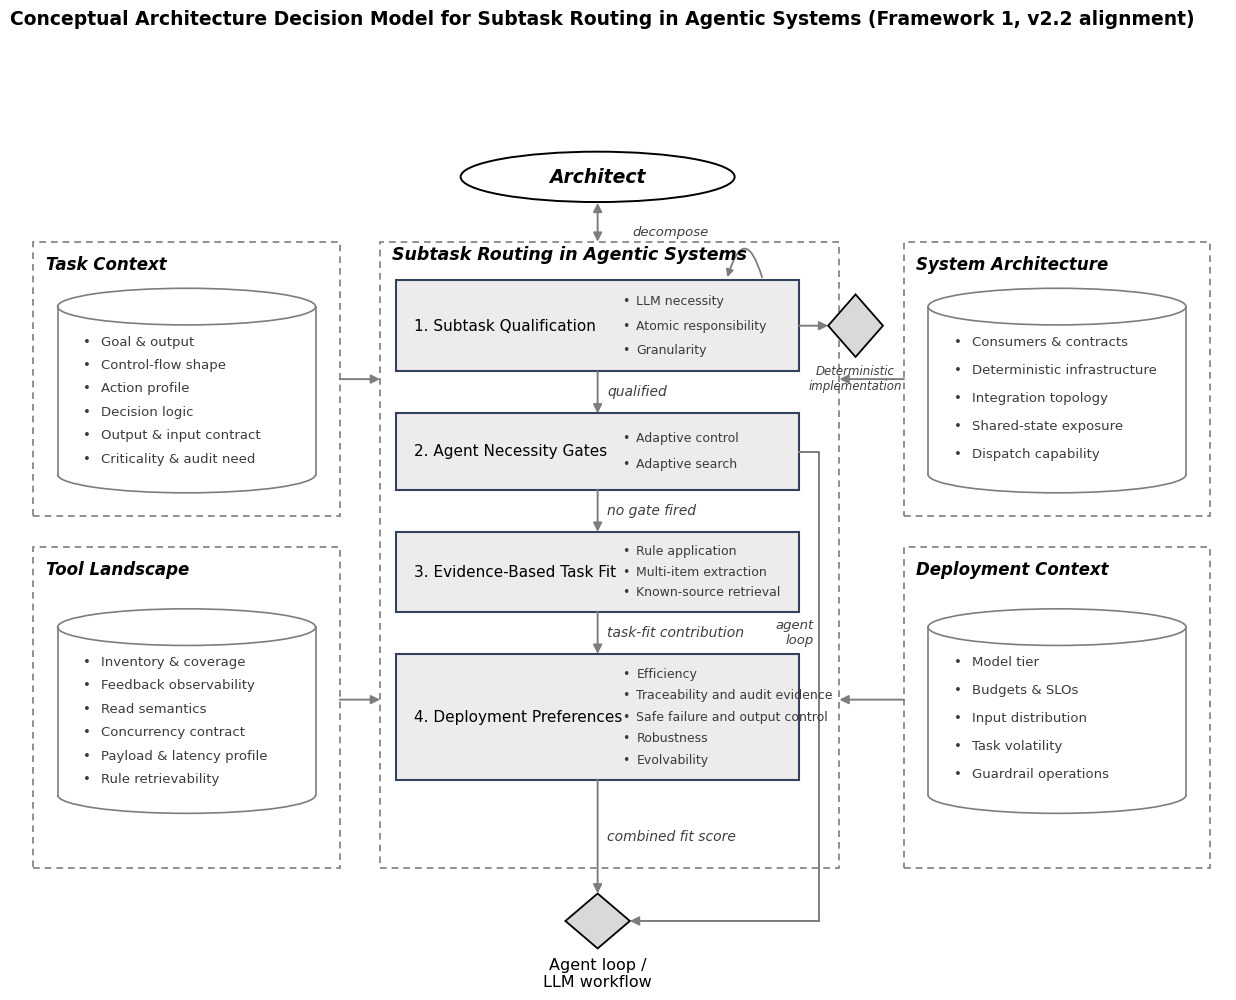

In [15]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Rectangle, Polygon, Arc, FancyArrowPatch

GREY = "#7d7d7d"; DARK = "#3b3b3b"; BOXF = "#ececec"; BOXE = "#33415c"
DIA = "#d9d9d9"; TXT = "#3f3f3f"

fig, ax = plt.subplots(figsize=(15.6, 11.2))
ax.set_xlim(0, 150); ax.set_ylim(-10, 103); ax.axis("off")
fig.suptitle("Conceptual Architecture Decision Model for Subtask Routing in Agentic "
             "Systems (Framework 1, v2.2 alignment)", fontsize=13.5, fontweight="bold",
             y=0.985)

def dashed_panel(x, y, w, h, title):
    ax.add_patch(Rectangle((x, y), w, h, fill=False, edgecolor=GREY,
                           linestyle=(0, (4, 3)), linewidth=1.2))
    ax.text(x + 1.5, y + h - 3, title, fontsize=12, fontweight="bold",
            fontstyle="italic", color="black", va="center")

def cylinder(cx, top_y, w, h, bullets):
    ry = 2.4
    ax.add_patch(Ellipse((cx, top_y), w, 2 * ry, fill=False, edgecolor=GREY, lw=1.2))
    ax.plot([cx - w / 2, cx - w / 2], [top_y, top_y - h], color=GREY, lw=1.2)
    ax.plot([cx + w / 2, cx + w / 2], [top_y, top_y - h], color=GREY, lw=1.2)
    ax.add_patch(Arc((cx, top_y - h), w, 2 * ry, theta1=180, theta2=360,
                     edgecolor=GREY, lw=1.2))
    n = len(bullets)
    y0 = top_y - ry - 2.2
    step = (h - ry - 1.2) / max(n, 1)
    for i, b in enumerate(bullets):
        ax.text(cx - w / 2 + 3.2, y0 - i * step, "•", fontsize=9.5, color=DARK,
                va="center")
        ax.text(cx - w / 2 + 5.4, y0 - i * step, b, fontsize=9.5, color=DARK,
                va="center")

def stage_box(x, y, w, h, num_title, bullets):
    ax.add_patch(Rectangle((x, y), w, h, facecolor=BOXF, edgecolor=BOXE, lw=1.5))
    ax.text(x + 2.2, y + h / 2, num_title, fontsize=11, color="black", va="center")
    n = len(bullets)
    step = min(3.4, (h - 2.4) / max(n, 1))
    y0 = y + h / 2 + (n - 1) * step / 2
    for i, b in enumerate(bullets):
        ax.text(x + w * 0.56, y0 - i * step, "•", fontsize=9, color=DARK, va="center")
        ax.text(x + w * 0.56 + 1.8, y0 - i * step, b, fontsize=9, color=DARK, va="center")

def diamond(cx, cy, hw, hh):
    ax.add_patch(Polygon([(cx - hw, cy), (cx, cy + hh), (cx + hw, cy), (cx, cy - hh)],
                         closed=True, facecolor=DIA, edgecolor="black", lw=1.3))

def arrow(p0, p1, label=None, lx=None, ly=None, double=False, ha="left"):
    ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle="<|-|>" if double else "-|>",
                                 mutation_scale=13, color=GREY, lw=1.4,
                                 shrinkA=0, shrinkB=0))
    if label:
        ax.text(lx, ly, label, fontsize=10, fontstyle="italic", color=TXT, ha=ha,
                va="center")

# ---- architect ----
ax.add_patch(Ellipse((72, 96.5), 34, 6.6, fill=False, edgecolor="black", lw=1.4))
ax.text(72, 96.5, "Architect", fontsize=13.5, fontweight="bold", fontstyle="italic",
        ha="center", va="center")
arrow((72, 93.1), (72, 88), double=True)

# ---- central frame ----
ax.add_patch(Rectangle((45, 6), 57, 82, fill=False, edgecolor=GREY,
                       linestyle=(0, (4, 3)), linewidth=1.2))
ax.text(46.5, 85.6, "Subtask Routing in Agentic Systems", fontsize=12.5,
        fontweight="bold", fontstyle="italic")

# ---- stage boxes ----
stage_box(47, 71, 50, 12, "1. Subtask Qualification",
          ["LLM necessity", "Atomic responsibility", "Granularity"])
stage_box(47, 55.5, 50, 10, "2. Agent Necessity Gates",
          ["Adaptive control", "Adaptive search"])
stage_box(47, 39.5, 50, 10.5, "3. Evidence-Based Task Fit",
          ["Rule application", "Multi-item extraction", "Known-source retrieval"])
stage_box(47, 17.5, 50, 16.5, "4. Deployment Preferences",
          ["Efficiency", "Traceability and audit evidence",
           "Safe failure and output control", "Robustness", "Evolvability"])

# ---- stage arrows ----
arrow((72, 71), (72, 65.5), "qualified", 73.2, 68.3)
arrow((72, 55.5), (72, 50), "no gate fired", 73.2, 52.8)
arrow((72, 39.5), (72, 34), "task-fit contribution", 73.2, 36.8)
arrow((72, 17.5), (72, 2.6), "combined fit score", 73.2, 10)

# ---- decompose self-loop ----
ax.add_patch(FancyArrowPatch((92.5, 83), (88, 83), arrowstyle="-|>", mutation_scale=11,
                             color=GREY, lw=1.3,
                             connectionstyle="arc3,rad=1.7"))
ax.text(85.8, 89.2, "decompose", fontsize=9.5, fontstyle="italic", color=TXT,
        ha="right", va="center")

# ---- deterministic implementation diamond ----
arrow((97, 77), (100.6, 77))
diamond(104.0, 77, 3.4, 4.1)
ax.text(104.0, 71.9, "Deterministic\nimplementation", fontsize=8.5, fontstyle="italic",
        color=TXT, ha="center", va="top")

# ---- agent-loop bypass ----
ax.plot([97, 99.5, 99.5], [60.5, 60.5, -1], color=GREY, lw=1.4)
ax.add_patch(FancyArrowPatch((99.5, -1), (76, -1), arrowstyle="-|>", mutation_scale=13,
                             color=GREY, lw=1.4, shrinkA=0, shrinkB=0))
ax.text(98.8, 36.8, "agent\nloop", fontsize=9.5, fontstyle="italic", color=TXT,
        ha="right", va="center")

# ---- final diamond ----
diamond(72, -1, 4, 3.6)
ax.text(72, -5.8, "Agent loop /\nLLM workflow", fontsize=11.5, ha="center", va="top")

# ---- side panels ----
dashed_panel(2, 52, 38, 36, "Task Context")
cylinder(21, 79.5, 32, 22,
         ["Goal & output", "Control-flow shape", "Action profile", "Decision logic",
          "Output & input contract", "Criticality & audit need"])
dashed_panel(2, 6, 38, 42, "Tool Landscape")
cylinder(21, 37.5, 32, 22,
         ["Inventory & coverage", "Feedback observability", "Read semantics",
          "Concurrency contract", "Payload & latency profile", "Rule retrievability"])
dashed_panel(110, 52, 38, 36, "System Architecture")
cylinder(129, 79.5, 32, 22,
         ["Consumers & contracts", "Deterministic infrastructure",
          "Integration topology", "Shared-state exposure", "Dispatch capability"])
dashed_panel(110, 6, 38, 42, "Deployment Context")
cylinder(129, 37.5, 32, 22,
         ["Model tier", "Budgets & SLOs", "Input distribution", "Task volatility",
          "Guardrail operations"])

# ---- panel connectors ----
arrow((40, 70), (45, 70))
arrow((40, 28), (45, 28))
arrow((110, 70), (102, 70))
arrow((110, 28), (102, 28))

plt.show()

*Reading the figure against the sheet:* a subtask enters at the top; steps 1–2 are the **structural** stage (any "yes" exits the scoring entirely — deterministic implementation, decomposition re-entry, or agent loop), and only *no gate fired* reaches the **weighted** stage, where the evidence-based task-fit block (T1–T3) and the architect-weighted deployment block (P1–P6) produce the combined fit score. The model deliberately contains no capability numbers — those live in the Decision Sheet (5.3) and its rulebook (5.3a); Framework 1 states the process and its information sources, Framework 2 states the evidence-bearing decision rules.

### Ergebnisse in einfacher Sprache (v2.2)

v2.2 ist die wissenschaftliche Endabnahme des Scorings. Jede Zahl im Bogen folgt jetzt aus einem **expliziten Regelwerk** (5.3a): Erfolgsraten werden auf gleicher Basis in Bänder übersetzt (≥90% → 3, 50–89% → 2, <50% → 1 — Bandbreite über dem 10,2%-Messrauschen), Kosten in Ratio-Bänder, Fehlerrichtung als Anteil gefährlicher Fehler, Nachvollziehbarkeit und Schema-Garantie als Konstruktions-Rubrik. Die wichtigste neue Regel ist die **Zulassungsregel für Task-Fit-Kriterien**: *Nur was in den Experimenten mindestens einen Band-Schritt Erfolgs-Unterschied zwischen den Paradigmen zeigt, wird bewertet.* Danach flog das alte Runtime-Structure-Kriterium raus — auf seinen Zellen liegen State Machine (77%) und Agent (85%) im selben Band, und seine echten Vorteile (Kosten, Konstanz, Schema) stecken schon in P1/P2/P4; es lebt weiter als Bauform W2 am „Nein"-Pfad von Q4. Dafür kam das **gemessene** T2 rein (Multi-item extraction: Planobjekt 2/5, Map-Form 2/3, Agent 5/5 bei Kostenparität — IT-069). Der T-Block sind jetzt genau die drei Strukturen mit echten Erfolgs-Differenzialen: Regeln (3/2), Extraktion (2/3), Retrieval (3/1). Die P-Scores sind nachgerechnet und dokumentiert (P1 auf Default-Region-Basis mit C/E-Ausnahmen; P4 als Maschine-oder-Mensch-Frage; P5 eng auf Messy Input mit D-Gegenbefund; P6 als einziger nicht gemessener Wert, amber). Der Backtest bestätigt: **Alle 30 gemessenen Task-Gruppen routen korrekt** — 28 voll gemessen, 2 mit benanntem abgeleiteten Rest (W2 auf Read-Branches, B2-Synthese nach Aktionen), und die Streichung des alten Kriteriums hat keine einzige Zelle gekippt. Zum Abschluss wurde auch **Framework 1** an die neue Struktur angeglichen: das *Conceptual Architecture Decision Model* (5.11) zeigt dieselben vier Blöcke des Bogens als Prozess, eingebettet in die vier Wissensquellen, aus denen ein Architekt die Antworten tatsächlich zieht.

## 6. Changelog and open items

### v1.2 → v1.3 (repr.): two-stage sheet. — v1.3 → v1.4 (content): review iteration. — v1.4 → v1.5 (repr.): three layers + completeness audit. — v1.5 → v2.0 (content): mandatory-constrained fit matrix. — v2.0 → v2.1 (structure): two-table restructuring, adoption-checked (three corrections; new T retrieval criterion).

### v2.1 → v2.2 (scoring finalization, 2026-08-03 — after the IT-069 confirmation sweep)

1. **Scoring rulebook made explicit** (5.3a): T-capability bands (≥90/50–89/<50, same pooled basis both sides, band width > 10.2% flip noise), the **T-admission rule** (scored only with ≥1-band same-basis differential), P1 cost-ratio bands over the governed region, P3 dangerous-error-share rule, P2/P4 construction rubric, P5 scope+band, P6 status rule. Every capability number now derives from a rule plus named cells.
2. **Former runtime-structure criterion removed from the scoring** by the admission rule: band-equal (SM 58/75 = 77% vs agent 64/75 = 85%, both band 2; reference tier 5/5 both); its measured advantages are P1/P2/P4 content, counted once. It persists as **build form W2** on Q4's "no"-path (enumerable branching, checkable repeat-until, data-bounded iteration) with check C1 — the removal flipped no cell (verified).
3. **T2 — Multi-item extraction success admitted** (IT-069, measured on both sides): plan object 2/5 · map form 2/3 (band 2) · agent 5/5 (band 3) at cost parity; question scoped to unstructured text (structured mappings → Q1); form **W4** + build rule **B1** (incl. derived item-count guard). The task-fit block is now T1 Rule success (3/2) · T2 Extraction success (2/3) · T3 Retrieval success (3/1).
4. **P-scores re-derived under the rulebook**: P1 = 3/1 on the governed-region basis (median 3.6×; C/E exceptions documented), P4 reframed as the machine-consumer question, P5 scoped to messy input (2/3, D counter-evidence cited), P2/P3 confirmed, P6 marked as the only unmeasured score (amber, Phase 3).
5. **Verification and full-corpus backtest re-run**: totality, gate invariance (18k+ combinations), neutral equivalence, the author's example profile reproduced (30 : 27 with the rulebook-correct effective weight), and 30/30 task groups correctly routed — 28 measured, 2 design-tagged with the named open confirmations.
6. **Framework 1 re-formalized** as the **Conceptual Architecture Decision Model for Subtask Routing in Agentic Systems** (5.11): four decision steps mirroring the sheet's blocks (Q1–Q3 · Q4–Q5 · T1–T3 · P1–P6) embedded in four knowledge stores (Task Context, Tool Landscape, System Architecture, Deployment Context). Pure re-representation — it supersedes the Reference-Architecture *form* (Phase 2b notebook §6, which stays frozen); no routing content changed.

### Open items

Exactly two derived elements remain, each with a named confirmation path: **(a)** B2 post-action synthesis (three-stage form on the s3 instances — measured for reads, derived for actions); **(b)** the W2 build note on *read-conditional* branches (state machine measured on action outcomes only; f-med-2 sweep would close it). Derived guard: B1 item-count check (targets the observed IT-069 failure mode, untested). Phase 3 validates: deployment weights and M semantics, the band thresholds, Q3 warning conditions, P6 volatility criteria (row 6.2). Hybrid-leaf case study → Phase 4; payload amber tail beyond ≈19k/≈41k input tokens. The four-condition router evaluation remains the next empirical step; Stage 1 + Stage 2 with neutral weights is the rule set Condition 4 implements.

### Freeze (IT-071, 2026-08-03)

**TADF v2.2 is frozen at this state** as the output of the DSR design cycle: Framework 1 = the Conceptual Architecture Decision Model (5.11), Framework 2 = the Decision Sheet with scoring rulebook, workflow forms W1–W4, build rules B1–B10 and capability checks C1–C6. The freeze followed a full checkup of the frameworks against the complete evidence base (all iteration-log findings cross-checked against gates, criteria, design knowledge, and the 30-group backtest — no paradigm-relevant result is uncarried; method-level findings are deliberately thesis-text content, not framework content). Per the IT-062 versioning discipline this notebook is not edited retroactively from here; the **evaluation phase (DSR: ex-post evaluation)** proceeds in new artifacts — the four-condition router evaluation on the recorded trajectories, and the Phase 3 validation of the deployment weights, M semantics, band thresholds, and P6 volatility criteria. The two named confirmation sweeps above remain optional deepenings, not freeze blockers.

---

*Version note.* This notebook is the v1.3–v2.2 reference; earlier forms are preserved in the repository history of this file. Per the IT‑062 discipline, `results_analysis.ipynb` stays frozen at v1 and `results_analysis_phase2b.ipynb` at v1.2; subsequent versions continue here or in a successor notebook, never retroactively.

## 7. Evaluation phase — comparative-performance preview (post-freeze)

*Status.* This section **postdates the freeze** (IT-071) and belongs to the **evaluation phase**, not to the design cycle: Sections 1–6 — the frozen v2.2 artifact — are unchanged; nothing here alters a gate, criterion, score, or rule. It quantifies, at group level, what the frozen router is worth against naive baselines, as a preview of the four-condition router evaluation (which will run at instance level on the recorded trajectories, including latency).

*Data basis and honesty.* The comparison uses the **frozen pooled group numbers** of the analysis notebooks — the 17 measured task groups with a clean same-basis success pair for both paradigms (**530 instance-runs** in total). Where the sheet routes to the workflow with a mandatory build form, the workflow side is that form's measured number (x1/s1 and P-b/s2: the state machine). Excluded by construction: the decompose/no-LLM groups (their correct outcome is *restructuring* — every routing baseline would be penalized identically), and four groups without a clean same-basis pooled pair (f-med-3 mixed n, x3 agent side, P-d pooled, H pooled anchor). Latency is deliberately **not** aggregated here: it was logged per run but never banded as a primary metric (P1 treats cost and latency as one token-bound criterion); the instance-level evaluation will compute it from the stored `latency_s` fields.

**Baselines.** *Oracle* = per group the better paradigm (upper bound); *always agent* / *always workflow* = fixed choice; *random* = expected value of a fair coin per group (the mean of the two fixed choices); *always worse* = per group the worse paradigm (lower bound).

In [16]:
# Frozen pooled group numbers (same basis both sides; W = the routed build form
# where the sheet mandates one). Source columns: analysis notebooks / backtest 5.9b.
EVAL_GROUPS = [
    # (group, n, W_success, A_success, v2.2-routed side)
    ("A-high",  25, 14, 23, "A"),   # 56% vs 92% (IT-042)
    ("B",       15, 15,  6, "W"),   # T3 cell (IT-043)
    ("C",       15, 15, 15, "W"),   # ceiling parity (IT-044)
    ("D",       75, 75, 60, "W"),   # T1 cell (IT-045)
    ("E",       75, 57, 48, "W"),   # checking (IT-046)
    ("f-high",  15,  0, 13, "A"),   # gate Q4 (IT-047)
    ("f-med-4",  5,  5,  5, "W"),   # identical bulk
    ("G",       15, 10, 15, "A"),   # gate Q5 (IT-024/051)
    ("P-a",     25, 25, 25, "W"),   # data-bounded iteration
    ("P-b/s2",  25, 14, 15, "W"),   # W2 build (IT-068)
    ("P-c",     25, 12, 24, "A"),   # gate Q5
    ("x1/s1",   25, 19, 24, "W"),   # T1 + W2 build (IT-068)
    ("x2",      25,  0, 24, "A"),   # gate Q5
    ("L",       90, 86, 90, "W"),   # payload families (IT-061/062)
    ("m1",      25,  0, 25, "A"),   # gate Q4 (IT-065)
    ("m2",      25,  0,  0, "W"),   # both-zero build-mandate cell (B9)
    ("m3",      25,  0, 16, "A"),   # gate Q4 (IT-065)
]

N = sum(g[1] for g in EVAL_GROUPS)
def _tot(pick):
    return sum(pick(g) for g in EVAL_GROUPS)
S = {
    "Oracle (per-group better)":  _tot(lambda g: max(g[2], g[3])),
    "TADF-routed (v2.2)":         _tot(lambda g: g[2] if g[4] == "W" else g[3]),
    "Always agent":               _tot(lambda g: g[3]),
    "Random (expected)":          (_tot(lambda g: g[2]) + _tot(lambda g: g[3])) / 2,
    "Always workflow":            _tot(lambda g: g[2]),
    "Always worse":               _tot(lambda g: min(g[2], g[3])),
}
RATE = {k: v / N for k, v in S.items()}
# per-group rates for the distribution view
PG = {
    "Oracle (per-group better)": [max(w, a) / n for _, n, w, a, _r in EVAL_GROUPS],
    "TADF-routed (v2.2)":        [(w if r == "W" else a) / n for _, n, w, a, r in EVAL_GROUPS],
    "Always agent":              [a / n for _, n, w, a, _r in EVAL_GROUPS],
    "Random (expected)":         [(w + a) / 2 / n for _, n, w, a, _r in EVAL_GROUPS],
    "Always workflow":           [w / n for _, n, w, a, _r in EVAL_GROUPS],
    "Always worse":              [min(w, a) / n for _, n, w, a, _r in EVAL_GROUPS],
}
# cost basis (governed region, tokens per SOLVED task, ratio to the cheaper side):
# agent family ratios from the frozen census; workflow = 1x by construction.
AGENT_RATIOS = {"B": 6.4, "D": 7.7, "F": 2.8, "H": 2.1, "C": 0.83, "E": 1.0}
AGENT_MEDIAN = 3.6

tadf, rnd, worse, oracle = (S["TADF-routed (v2.2)"], S["Random (expected)"],
                            S["Always worse"], S["Oracle (per-group better)"])
print(f"n = {N} instance-runs across {len(EVAL_GROUPS)} measured task groups\n")
for k, v in S.items():
    print(f"  {k:28s} {v:6.1f}/{N}  = {v/N:6.1%}")
print(f"\n  TADF vs random:        +{(tadf-rnd)/N:.1%} points")
print(f"  TADF vs always-worse:  +{(tadf-worse)/N:.1%} points")
print(f"  TADF captures {tadf/oracle:.1%} of the oracle "
      f"(gap: P-b/s2 and x1 — band-equal cells routed to the 0.27–0.36x-cost form)")
print(f"\n  Cost (governed region, per solved task): workflow-routed 1x vs agent "
      f"median {AGENT_MEDIAN}x -> vs always-agent ~{1-1/AGENT_MEDIAN:.0%} cheaper, "
      f"vs random (expected {(1+AGENT_MEDIAN)/2:.1f}x) ~{1-2/(1+AGENT_MEDIAN):.0%} cheaper.")

n = 530 instance-runs across 17 measured task groups

  Oracle (per-group better)     461.0/530  =  87.0%
  TADF-routed (v2.2)            451.0/530  =  85.1%
  Always agent                  428.0/530  =  80.8%
  Random (expected)             387.5/530  =  73.1%
  Always workflow               347.0/530  =  65.5%
  Always worse                  314.0/530  =  59.2%

  TADF vs random:        +12.0% points
  TADF vs always-worse:  +25.8% points
  TADF captures 97.8% of the oracle (gap: P-b/s2 and x1 — band-equal cells routed to the 0.27–0.36x-cost form)

  Cost (governed region, per solved task): workflow-routed 1x vs agent median 3.6x -> vs always-agent ~72% cheaper, vs random (expected 2.3x) ~57% cheaper.


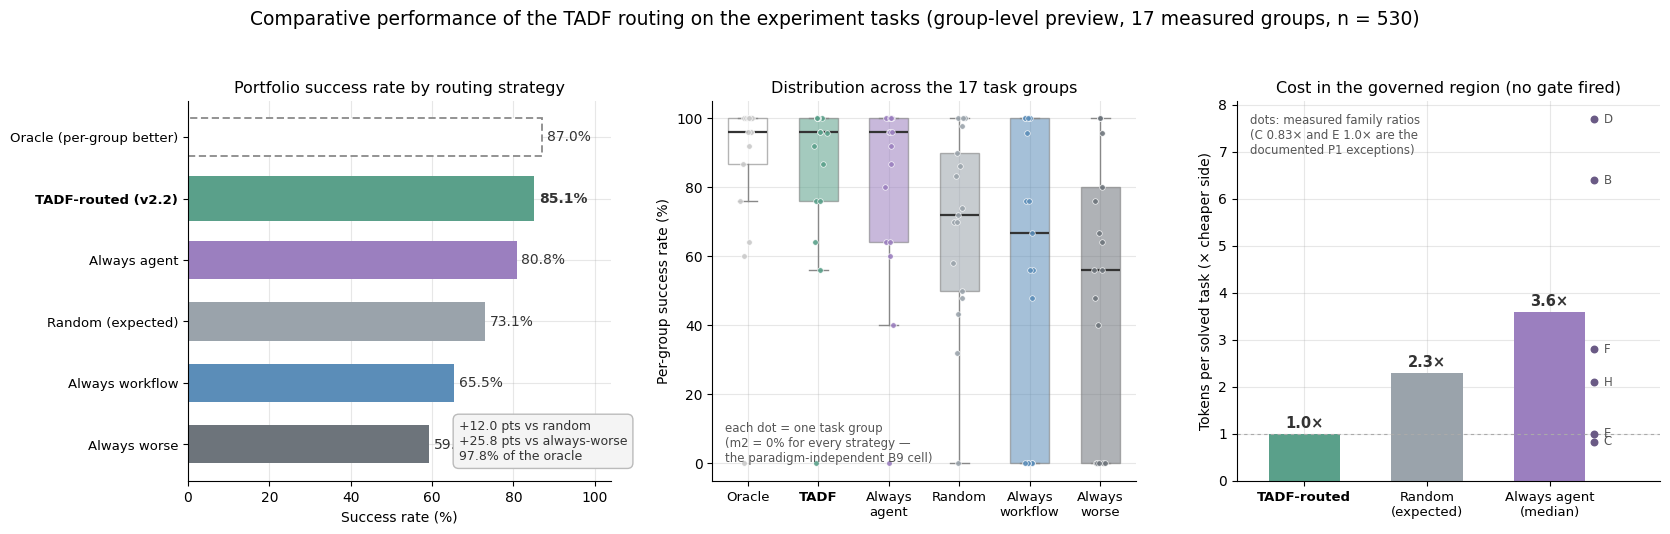

In [17]:
import matplotlib.pyplot as plt
import numpy as np

C_TADF = "#5aa08a"; C_WF = "#5b8db8"; C_AG = "#9b7fbf"
C_RND = "#9aa3ab"; C_WRS = "#6d747b"; C_ORC = "#c9c9c9"
STRATS = list(S.keys())  # oracle .. always worse (sorted by construction)
COLORS = {"Oracle (per-group better)": C_ORC, "TADF-routed (v2.2)": C_TADF,
          "Always agent": C_AG, "Random (expected)": C_RND,
          "Always workflow": C_WF, "Always worse": C_WRS}

fig, axes = plt.subplots(1, 3, figsize=(16.8, 5.4))
fig.suptitle("Comparative performance of the TADF routing on the experiment tasks "
             f"(group-level preview, {len(EVAL_GROUPS)} measured groups, n = {N})",
             fontsize=13.5)

# ---- (a) portfolio success rate ----
ax = axes[0]
ys = np.arange(len(STRATS))[::-1]
vals = [RATE[s] * 100 for s in STRATS]
for y, s, v in zip(ys, STRATS, vals):
    kw = dict(color=COLORS[s], edgecolor="none", height=0.62)
    if s.startswith("Oracle"):
        kw.update(color="white", edgecolor="#8a8a8a", linestyle=(0, (4, 2)), linewidth=1.3)
    if s.startswith("TADF"):
        kw.update(height=0.72)
    ax.barh(y, v, **kw)
    ax.text(v + 1.2, y, f"{v:.1f}%", va="center", fontsize=10,
            fontweight="bold" if s.startswith("TADF") else "normal", color="#333")
ax.set_yticks(ys)
ax.set_yticklabels(STRATS, fontsize=9.5)
ax.get_yticklabels()[STRATS.index("TADF-routed (v2.2)")].set_fontweight("bold")
ax.set_xlim(0, 104)
ax.set_xlabel("Success rate (%)", fontsize=10)
ax.set_title("Portfolio success rate by routing strategy", fontsize=11.5)
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
ax.annotate("+12.0 pts vs random\n+25.8 pts vs always-worse\n97.8% of the oracle",
            xy=(0.64, 0.055), xycoords="axes fraction", fontsize=9, color="#333",
            bbox=dict(boxstyle="round,pad=0.45", fc="#f4f4f4", ec="#bbb"))

# ---- (b) per-group distribution ----
ax = axes[1]
data = [np.array(PG[s]) * 100 for s in STRATS]
bp = ax.boxplot(data, vert=True, patch_artist=True, widths=0.55,
                medianprops=dict(color="#333", lw=1.6),
                whiskerprops=dict(color="#888"), capprops=dict(color="#888"),
                flierprops=dict(marker=""))
for patch, s in zip(bp["boxes"], STRATS):
    patch.set_facecolor(COLORS[s] if not s.startswith("Oracle") else "white")
    patch.set_alpha(0.55)
    patch.set_edgecolor("#777")
rng = np.random.default_rng(42)
for i, (s, d) in enumerate(zip(STRATS, data), start=1):
    x = rng.normal(i, 0.055, size=len(d))
    ax.scatter(x, d, s=16, color=COLORS[s], edgecolor="white", linewidth=0.5,
               zorder=3, alpha=0.9)
ax.set_xticklabels(["Oracle", "TADF", "Always\nagent", "Random", "Always\nworkflow",
                    "Always\nworse"], fontsize=9.5)
ax.get_xticklabels()[1].set_fontweight("bold")
ax.set_ylabel("Per-group success rate (%)", fontsize=10)
ax.set_title("Distribution across the 17 task groups", fontsize=11.5)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
ax.text(0.03, 0.05, "each dot = one task group\n(m2 = 0% for every strategy —\n"
        "the paradigm-independent B9 cell)", transform=ax.transAxes, fontsize=8.5,
        color="#555")

# ---- (c) cost per solved task (governed region) ----
ax = axes[2]
bars = [("TADF-routed", 1.0, C_TADF), ("Random\n(expected)", (1 + AGENT_MEDIAN) / 2, C_RND),
        ("Always agent\n(median)", AGENT_MEDIAN, C_AG)]
for i, (lbl, v, c) in enumerate(bars):
    ax.bar(i, v, width=0.58, color=c, edgecolor="none")
    ax.text(i, v + 0.12, f"{v:.1f}×", ha="center", fontsize=10.5, fontweight="bold",
            color="#333")
x_ag = 2
for fam, r in sorted(AGENT_RATIOS.items(), key=lambda kv: kv[1]):
    ax.scatter(x_ag + 0.36, r, s=22, color="#6a5a85", zorder=3)
    ax.text(x_ag + 0.44, r, fam, fontsize=8.5, va="center", color="#555")
ax.axhline(1.0, color="#aaa", lw=0.8, linestyle=(0, (3, 3)))
ax.set_xticks(range(3))
ax.set_xticklabels([b[0] for b in bars], fontsize=9.5)
ax.get_xticklabels()[0].set_fontweight("bold")
ax.set_xlim(-0.55, 2.9)
ax.set_ylabel("Tokens per solved task (× cheaper side)", fontsize=10)
ax.set_title("Cost in the governed region (no gate fired)", fontsize=11.5)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
ax.text(0.03, 0.86, "dots: measured family ratios\n(C 0.83× and E 1.0× are the\n"
        "documented P1 exceptions)", transform=ax.transAxes, fontsize=8.5, color="#555")

plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

*Reading.* **(a)** The frozen router reaches **85.1%** portfolio success — **+12.0 points over random routing**, **+25.8 over always-the-worse-paradigm**, and **97.8% of the oracle**; the remaining oracle gap is not error but documented intent (the two band-equal cells P-b/s2 and x1 route to the workflow build at 0.27–0.36× the agent's tokens). **(b)** The distribution view shows *why* fixed strategies lose: each carries structural-zero groups (always-workflow: the Q4/Q5 gate cells at 0%; always-agent: none at zero but the B/T3 cell at 40%), while TADF's per-group floor — apart from the paradigm-independent m2 cell — is the better paradigm's own floor. **(c)** In the governed region the routed side is the 1× side; the agent's median premium is 3.6× per solved task. These are group-level estimates from frozen pooled numbers — the citable instance-level numbers (including latency from `latency_s`) come from the four-condition router evaluation, of which this section is the preview.

*Cost–performance view.* The same numbers as one trade-off plot: success (y, 95% binomial CI on n = 530) against governed-region cost per solved task (x; workflow side = 1×, agent side = the measured 3.6× median with the family range as the horizontal bar). *Always worse* is omitted — on the gate cells the worse side solves zero tasks, so its cost per solved task diverges. The oracle's x-position is computed, not assumed: within the governed region it picks the agent on the two band-equal cells (P-b/s2, x1), which prices its 1.9-point success edge at roughly double the tokens (computed below: 1.97× vs 1.00×).

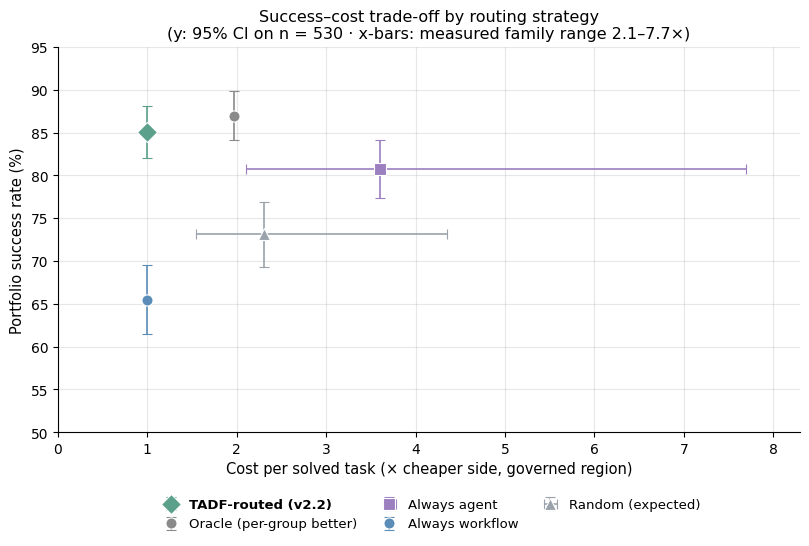

Oracle governed-region cost: 1.97x vs TADF 1.00x -> the oracle's +1.9 points cost +97% tokens.


In [18]:
import numpy as np
import matplotlib.pyplot as plt

CI = {k: 1.96 * np.sqrt((v / N) * (1 - v / N) / N) * 100 for k, v in S.items()}
gov = [g for g in EVAL_GROUPS if g[4] == "W"]          # governed region (no gate fired)
n_gov = sum(g[1] for g in gov)

def gov_cost(chooser):
    """Weighted governed-region cost ratio of a per-group paradigm chooser."""
    return sum(g[1] * (1.0 if chooser(g) == "W" else AGENT_MEDIAN) for g in gov) / n_gov

X = {
    "TADF-routed (v2.2)": gov_cost(lambda g: g[4]),                          # 1.0x
    "Oracle (per-group better)": gov_cost(lambda g: "W" if g[2] >= g[3] else "A"),
    "Always workflow": 1.0,
    "Always agent": AGENT_MEDIAN,
    "Random (expected)": (1.0 + AGENT_MEDIAN) / 2,
}
XERR = {"Always agent": ([AGENT_MEDIAN - 2.1], [7.7 - AGENT_MEDIAN]),        # family range
        "Random (expected)": ([(AGENT_MEDIAN - 2.1) / 2], [(7.7 - AGENT_MEDIAN) / 2])}
STYLE = {  # marker, color
    "TADF-routed (v2.2)":        ("D", C_TADF),
    "Oracle (per-group better)": ("o", "#8a8a8a"),
    "Always agent":              ("s", C_AG),
    "Always workflow":           ("o", C_WF),
    "Random (expected)":         ("^", C_RND),
}

fig, ax = plt.subplots(figsize=(8.2, 5.9))
for k, (mk, col) in STYLE.items():
    xe = XERR.get(k)
    ax.errorbar(X[k], RATE[k] * 100, yerr=CI[k], xerr=xe, fmt=mk, color=col,
                markersize=10 if k.startswith("TADF") else 8, capsize=3.5,
                elinewidth=1.2, markeredgecolor="white", markeredgewidth=0.8,
                zorder=3, label=k)
leg = ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=3,
                fontsize=9.5, frameon=False, handletextpad=0.4, columnspacing=1.4)
for t in leg.get_texts():
    if t.get_text().startswith("TADF"):
        t.set_fontweight("bold")
ax.set_xlim(0, 8.3)
ax.set_ylim(50, 95)
ax.set_xlabel("Cost per solved task (× cheaper side, governed region)", fontsize=10.5)
ax.set_ylabel("Portfolio success rate (%)", fontsize=10.5)
ax.set_title("Success–cost trade-off by routing strategy\n"
             "(y: 95% CI on n = 530 · x-bars: measured family range 2.1–7.7×)",
             fontsize=11.5)
ax.grid(alpha=0.3)
ax.set_axisbelow(True)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

print(f"Oracle governed-region cost: {X['Oracle (per-group better)']:.2f}x vs "
      f"TADF {X['TADF-routed (v2.2)']:.2f}x -> the oracle's +1.9 points cost "
      f"{X['Oracle (per-group better)'] / X['TADF-routed (v2.2)'] - 1:+.0%} tokens.")

## 8. TADF v3 — the interview-driven cycle: from Decision Sheet to conversational skill

*Status.* This section, like Section 7, **postdates the freeze** (IT-071) and documents the third design cycle (IT-073, IT-074). Nothing in Sections 1–6 is edited retroactively, and the v2.2 evidence base — every cell, band, score and gate threshold — is carried into v3 unchanged. What this cycle changed is the *instrument*: its delivery form, its scope around the route, and the rules that govern how it speaks.

**What drove it.** Twelve practitioner interviews (P01–P12, IT-073) evaluated the frozen v2.2 sheet. They confirmed the problem and the measured differences, and rejected two things: the spreadsheet as the place where an architecture decision happens, and the routing verdict as the end of the decision act. Their synthesis — in plain terms: talk to me, walk the whole task through even when a gate fires, tell me what to build and what environment questions decide deployability, keep knock-outs non-negotiable, and never let a score hide its source — became the specification for v3.

**The new shape.** TADF v3 is a conversational skill (`Framework v3/tadf/`) in four documents, one owner per concern:

- `SKILL.md` — the procedure: system context (SQ0–SQ3), task narrative (TQ0), the five gates in fixed order, task-fit criteria T1–T3, performance profile P1–P6, verdict, and a decision record shown once at exit.
- `references/evidence-and-scoring.md` — the numerical rulebook. This is the v2.2 sheet logic as prose and tables: gate evidence, fixed capability scores, the admission and count-once rules, M and eligibility, the component and tie rules.
- `references/design-knowledge.md` — the build knowledge in four categories: execution environment, build form, build rules, model checks. Delivered in full with every LLM verdict.
- `references/constructs-and-scope.md` — the definitions: task, workflow versus agent, where the control line runs, and the terms *consequential* and *tested rollback* that anchor the approval safeguard.

**How the sheet's three layers map into the skill.** Layer 1 (the core sheet) became the staged interview plus the scoring rulebook; layer 2 (design knowledge) became its own reference file with a fixed delivery order and phrasing; layer 3 (evidence provenance) became the gate-evidence and capability tables, trimmed to what a routing decision needs — the full provenance stays in the study. Framework 1's four decision steps survive as the interview's stages.

**The behavioural rules that the interviews added.** A fired gate still fixes the route (non-compensatory), but the interview continues into a design pass — the full walkthrough the practitioners asked for. The one exception is honest rather than complete: a task that needs no LLM (G1) stops at its verdict, because no deterministic build was ever measured. Knock-outs stay knock-outs: M can exclude a paradigm regardless of totals, and one weight-independent safeguard — human approval before any consequential action without a tested rollback — follows from confirmed task facts, not from a weight. Preferences are separated and sourced: the architect supplies only weights, cost and latency are asked apart, ceilings are constraints, and capability scores never move. Hybrid remains a system-level outcome: the skill routes tasks and says so at exit.

**What the live runs taught about the form itself.** Two failure modes appeared that no sheet ever had: the executing model *embellished* the design knowledge (plausible additions, silently dropped guard nodes) and *compressed* it (the compact per-task record swallowed the full design-knowledge section). Both were answered structurally — a closed knowledge base and closed-delivery rule (select and tailor from the file, never invent, never silently drop), and the decision record moved to the exit so the verdict with its complete design knowledge is the only per-task output. The finding generalises: a conversational instrument needs guardrails on its delivery, not only correct content.

**Versioning discipline.** The artifact itself lives and evolves in `Framework v3/tadf/`; this notebook documents the trajectory and stays unedited going forward, per the same rule that protected the earlier notebooks (IT-062). The adoption/rejection mapping against P01–P12 is recorded in IT-074 and the v3 changelog documents.

## 9. Evaluation 2 and design cycle 4 — the artifact under load, and what it changed

*Status.* This section documents the second (comparative) evaluation of the frozen TADF v3 skill (IT-075–IT-077) and the design cycle it triggered (IT-078). As before, nothing above is edited retroactively; the artifact itself lives in `Framework v3/tadf/`, and the full analysis notebook is `TADF_Workbench_Evaluation/evaluation02_results.ipynb`.

**Design.** The full WorkBench benchmark (690 tasks, 69 base templates, gpt-5.4-mini everywhere). The frozen skill routed all templates headless in benchmark mode, blind and before any run existed: 69/69 → workflow, no gate fired, and a second pass in reversed order agreed on all 69 verdicts — the instrument's first measured reliability datum for elicited inputs. Then both paradigms ran in full: the TADF workflow operationalization against the unmodified WorkBench Revisited agent harness, later in all four shipped agent configurations. The published per-model result (406/690 = 58.8%) served as external anchor and was reproduced in its exact configuration within 2.1 points (391/690 = 56.7%; per-domain deltas mostly ≤1 task), so the comparison is externally validated.

**Act one — the routing verdicts fail (2a).** With the workflow built *without* the artifact's build rules, the all-workflow routing lost: 41.6% against the agent's 50.1%, below random. But the mechanism was visible in the data: email, the only domain whose workflow had been through the pilot-and-freeze protocol, won clearly (68.9% vs 51.1%); the five unpiloted domains all lost. The evaluation had conflated router quality with executor quality — the verdicts presuppose a workflow built to the artifact's own design knowledge, and this one was not.

**Act two — the artifact's own knowledge is applied (2b).** One documented iteration implemented exactly the build rules the design knowledge already prescribed — a bounded re-plan round, a placeholder guard, per-item calls, fail-closed conditions — plus domain-general tool-semantics rules derived from 10-task dev slices, mirroring the email pilot. Nothing else changed. Result: **66.2%**, above all four agent variants (strongest: 60.9%), above the published anchor, at roughly half the agent's estimated token cost, reaching ~87% of the per-task oracle. The +24.6-point swing is the measured value of the design-knowledge component: routing and build knowledge are one instrument, and either alone underperforms.

| Condition | Success | Side effects |
|---|---|---|
| Workflow, no build rules (2a) | 41.6% | 148 |
| **TADF: routing + build rules (2b)** | **66.2%** | 119 |
| Agent, strongest variant (structured, domain tools) | 60.9% | 134 |
| Agent, paper configuration (reproduced anchor) | 56.7% | 137 |
| Published anchor | 58.8% | 209 |
| Random / Oracle (vs strongest agent) | 63.6% / 75.9% | — |

**What still went to the agent — and what it taught.** Among clearly discriminative templates the verdicts stood 15:7. The seven agent-won templates share one root: the deciding state exceeded what the read tools could expose (result caps on search, free-slot coverage), so the branch-table escape's silent precondition failed; a third pattern (superlatives over several reads) was an implementation gap, not a routing error. Nine templates were solved by nobody — the same feasibility floor the STS pilot saw on τ-bench, reported separately because no router can differentiate there.

**Design cycle 4 (IT-078) — three minimal changes, in force after the freeze.** First, G4 gained a second, always-asked primary question: can the planned reads make the deciding state fully visible (result caps, pagination, truncation)? If not, the branch-table escape is unavailable and G4 fires. Second, every workflow verdict now carries a one-line **mandatory minimum** (re-plan round, placeholder guard, per-item calls with count check, fail-closed conditions, dev-slice pilot) in every mode including headless — and states plainly that the routing evidence describes a workflow built with these components. Third, an **executor-commitment question** with a defined fallback: if the build will not implement the minimum, the route is kept but reported as conditional, with the named way out — explore with a guarded agent, then routinise. A prototype-versus-production *gate* was considered and rejected: lifecycle is context, not task structure. Gates, thresholds, capability scores and weights are unchanged; the nuanced side-effect evidence (the agent's failure direction depends on its loop variant) is recorded as a candidate for a future evidence revision, not applied.

**Versioning discipline.** Evaluation 2 ran end-to-end on the frozen v3 state (checksums in IT-075/IT-077); the cycle-4 changes apply from IT-078 onward. This notebook stays unedited going forward; the trajectory continues in the iteration log.